In [3]:
import pandas as pd
import numpy as np
from AnalysisSrc.assets import PlotCANIDFrequency, LoadPreprocessData
import matplotlib.pyplot as plt

In [39]:
def plot_can_id_comparison(Attack_Free, Attack, column='CAN_ID_Norm', n_samples=2000):
    """
    Plots Attack-Free and Attack datasets in separate subplots 
    (top: Attack-Free, bottom: Attack) against Time_Offset.

    Parameters:
        Attack_Free (pd.DataFrame): Dataset representing normal or attack-free data.
        Attack (pd.DataFrame): Dataset representing attack data.
        column (str): Column name to plot on the y-axis. Default is 'CAN_ID_Norm'.
        n_samples (int): Number of samples to plot. Default is 2000.
    """
    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    # --- Top subplot: Attack-Free ---
    axes[0].plot(Attack_Free['Time_Offset'][:n_samples], Attack_Free[column][:n_samples], color='tab:blue')
    axes[0].set_title(f'Attack-Free: {column}')
    axes[0].set_ylabel(column)
    axes[0].grid(True)

    # --- Bottom subplot: Attack ---
    axes[1].plot(Attack['Time_Offset'][:n_samples], Attack[column][:n_samples], color='tab:red')
    axes[1].set_title(f'Attack: {column}')
    axes[1].set_xlabel('Time_Offset')
    axes[1].set_ylabel(column)
    axes[1].grid(True)

    # --- Global layout ---
    plt.tight_layout()
    plt.show()

In [57]:
def load_all_datasets(Kia_DoS_L, Tesla_DoS_L, Sil_DoS_L, Gen_DoS_L):
    """
    Loads and preprocesses all DoS datasets (Kia, Tesla, Gen, Sil),
    and selects consistent feature columns.

    Parameters:
        Kia_DoS_L (str): Path to Kia DoS dataset CSV file.
        Tesla_DoS_L (str): Path to Tesla DoS dataset CSV file.
        Sil_DoS_L (str): Path to Sil DoS dataset CSV file.
        Gen_DoS_L (str): Path to Gen DoS dataset CSV file.

    Returns:
        tuple: (Kia_DoS, Tesla_DoS, Sil_DoS, Gen_DoS)
    """

    selected_cols = [
        'Time_Offset', 'CAN_ID_Norm', 'Time_Delta', 'Intra_ID_Time_Gap',
        'CAN_ID_Norm_Time_Delta', 'Time_Delta_Norm', 'Intra_ID_Time_Gap_Norm', 'Label'
    ]

    Kia_DoS_M = LoadPreprocessData(Kia_DoS_L)
    Tesla_DoS_M = LoadPreprocessData(Tesla_DoS_L)
    Sil_DoS_M = LoadPreprocessData(Sil_DoS_L)
    Gen_DoS_M = LoadPreprocessData(Gen_DoS_L)

    Kia_DoS = Kia_DoS_M[selected_cols]
    Tesla_DoS = Tesla_DoS_M[selected_cols]
    Sil_DoS = Sil_DoS_M[selected_cols]
    Gen_DoS = Gen_DoS_M[selected_cols]

    print("✅ All DoS datasets loaded and preprocessed successfully.")
    return Kia_DoS, Tesla_DoS, Sil_DoS, Gen_DoS

In [4]:
Kia_AF = LoadPreprocessData("Kia_AF.csv")
Tesla_AF = LoadPreprocessData("Tesla_AF.csv")
Gen_AF = LoadPreprocessData("Gen_AF.csv")
Gen_AF = Gen_AF[:600000]
Sil_AF = LoadPreprocessData("Sil_AF.csv")

/home/lisa/Arupreza/UIDS-II/AnalysisSrc/assets.py:17: DtypeWarning: Columns (20,22) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path + df)


In [5]:
Kia_AF = Kia_AF[['Time_Offset', 'CAN_ID_Norm', 'Time_Delta', 'Intra_ID_Time_Gap', 'CAN_ID_Norm_Time_Delta', 'Time_Delta_Norm', 'Intra_ID_Time_Gap_Norm', 'Label']]
Tesla_AF = Tesla_AF[['Time_Offset', 'CAN_ID_Norm', 'Time_Delta', 'Intra_ID_Time_Gap', 'CAN_ID_Norm_Time_Delta', 'Time_Delta_Norm', 'Intra_ID_Time_Gap_Norm', 'Label']]
Gen_AF = Gen_AF[['Time_Offset', 'CAN_ID_Norm', 'Time_Delta', 'Intra_ID_Time_Gap', 'CAN_ID_Norm_Time_Delta', 'Time_Delta_Norm', 'Intra_ID_Time_Gap_Norm', 'Label']]
Sil_AF = Sil_AF[['Time_Offset', 'CAN_ID_Norm', 'Time_Delta', 'Intra_ID_Time_Gap', 'CAN_ID_Norm_Time_Delta', 'Time_Delta_Norm', 'Intra_ID_Time_Gap_Norm', 'Label']]

DoS Analysis

In [58]:
Kia_DoS_L, Tesla_DoS_L, Sil_DoS_L, Gen_DoS_L = load_all_datasets("Kia_DoS_L.csv", "Tesla_DoS_L.csv", "Sil_DoS_L.csv", "Gen_DoS_L.csv")

/home/lisa/Arupreza/UIDS-II/AnalysisSrc/assets.py:17: DtypeWarning: Columns (20,22,23) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path + df)


✅ All DoS datasets loaded and preprocessed successfully.


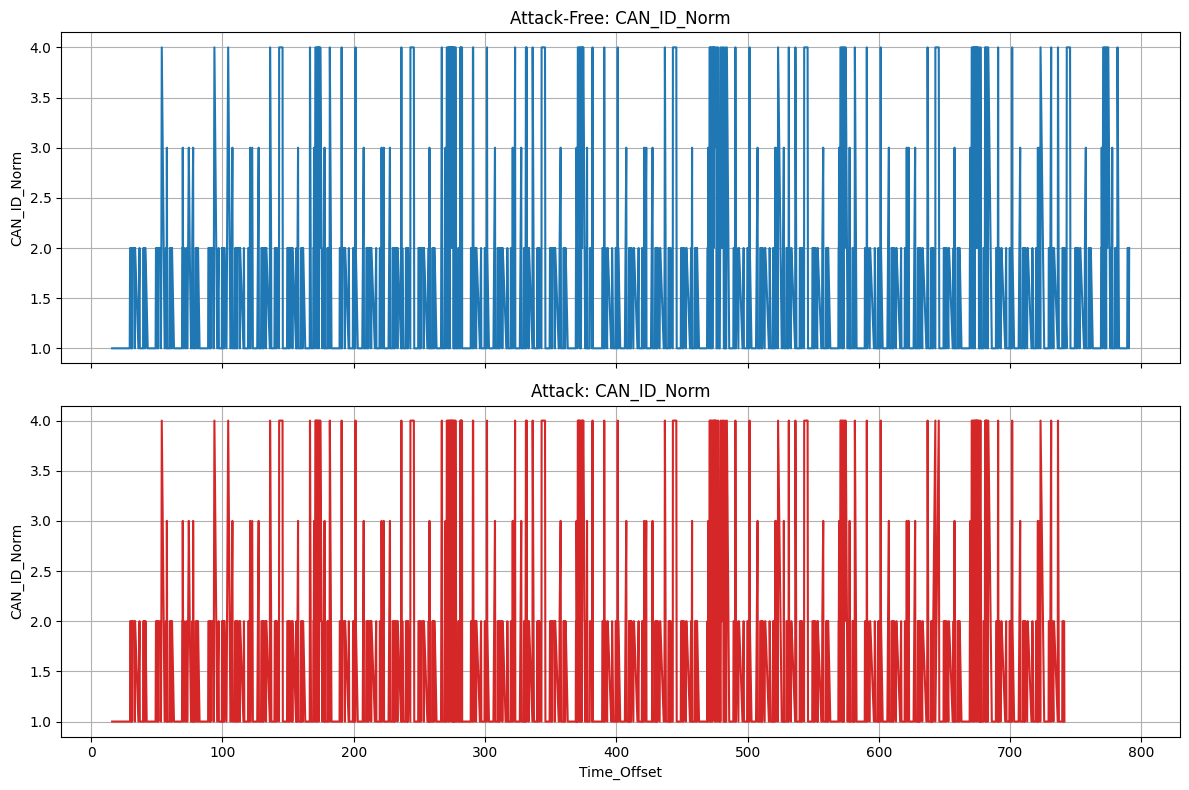

In [59]:
plot_can_id_comparison(Kia_AF, Kia_DoS_L, 'CAN_ID_Norm', 2000)

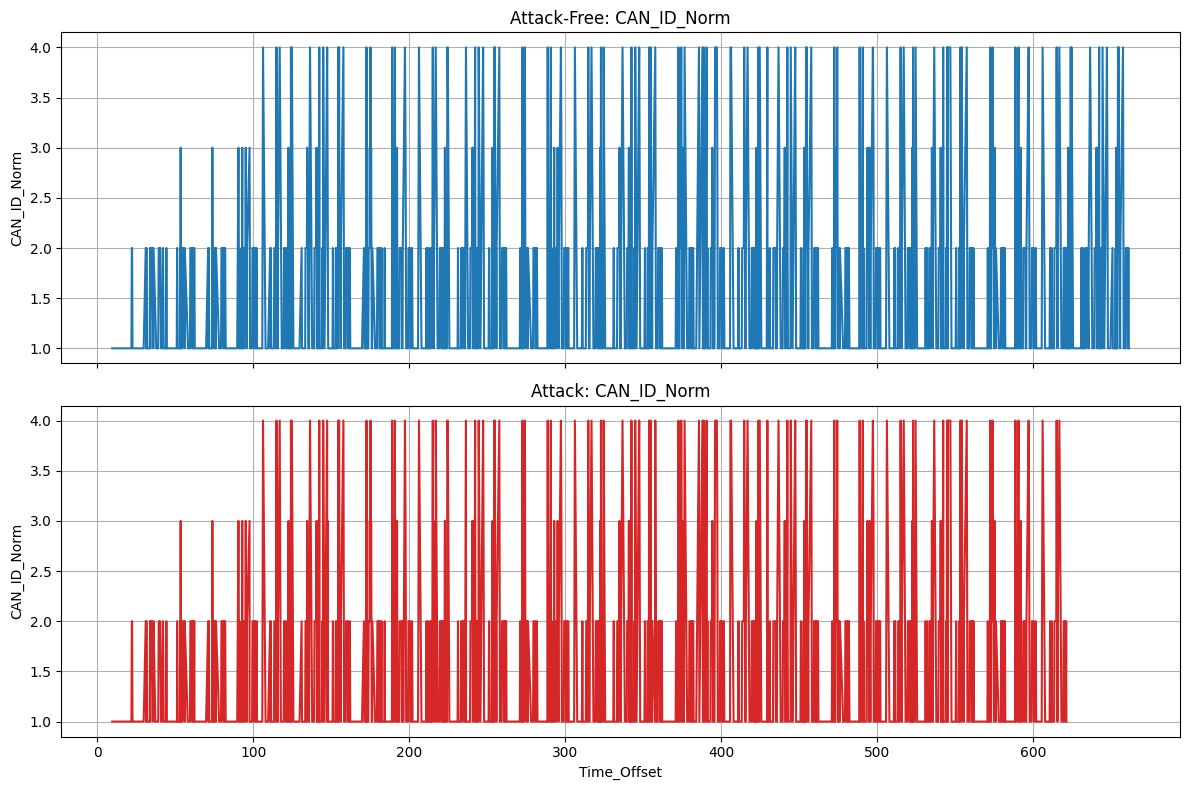

In [71]:
plot_can_id_comparison(Tesla_AF, Tesla_DoS_L, 'CAN_ID_Norm', 2000)

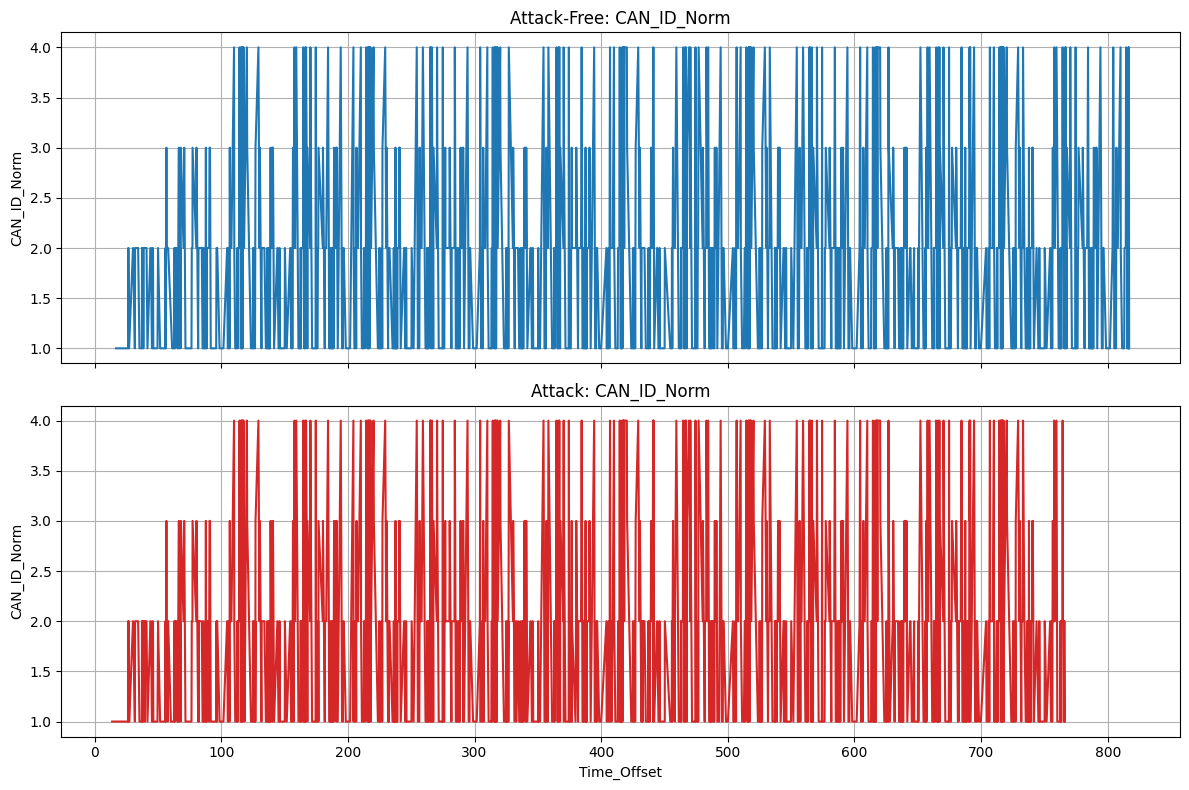

In [72]:
plot_can_id_comparison(Sil_AF, Sil_DoS_L, 'CAN_ID_Norm', 2000)

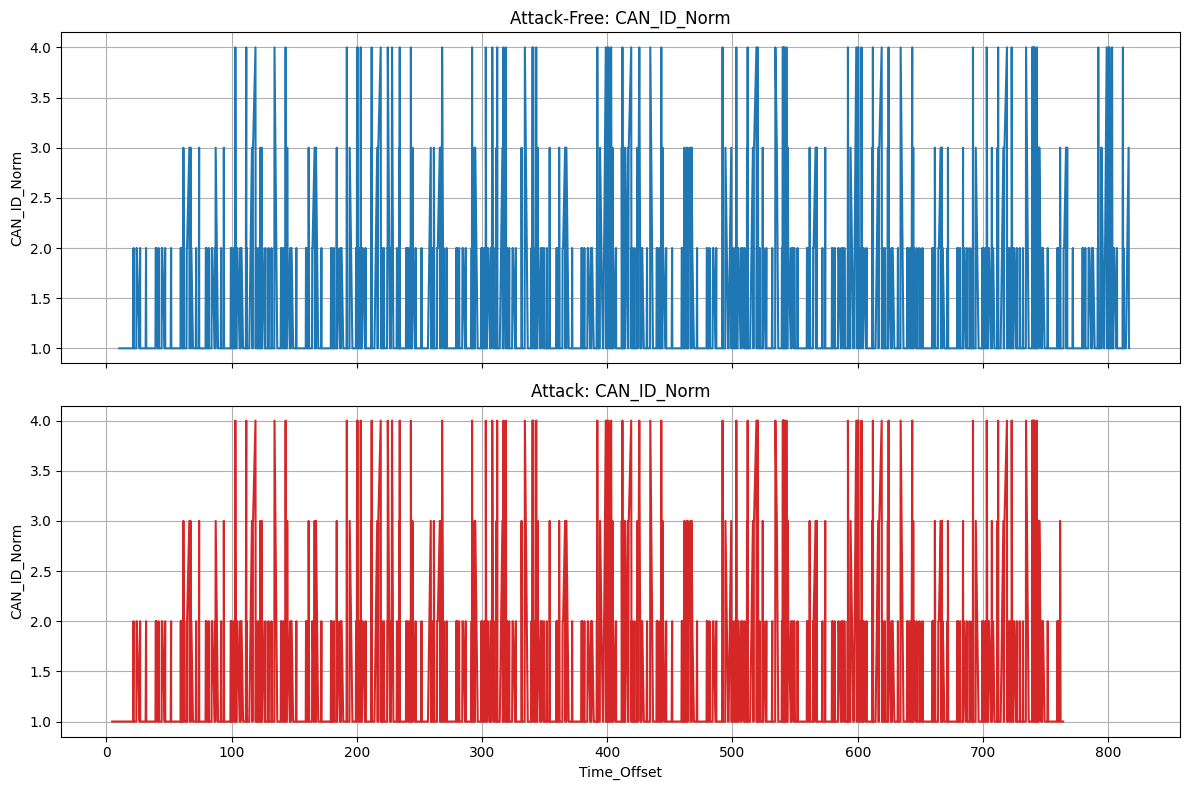

In [73]:
plot_can_id_comparison(Gen_AF, Gen_DoS_L, 'CAN_ID_Norm', 2000)

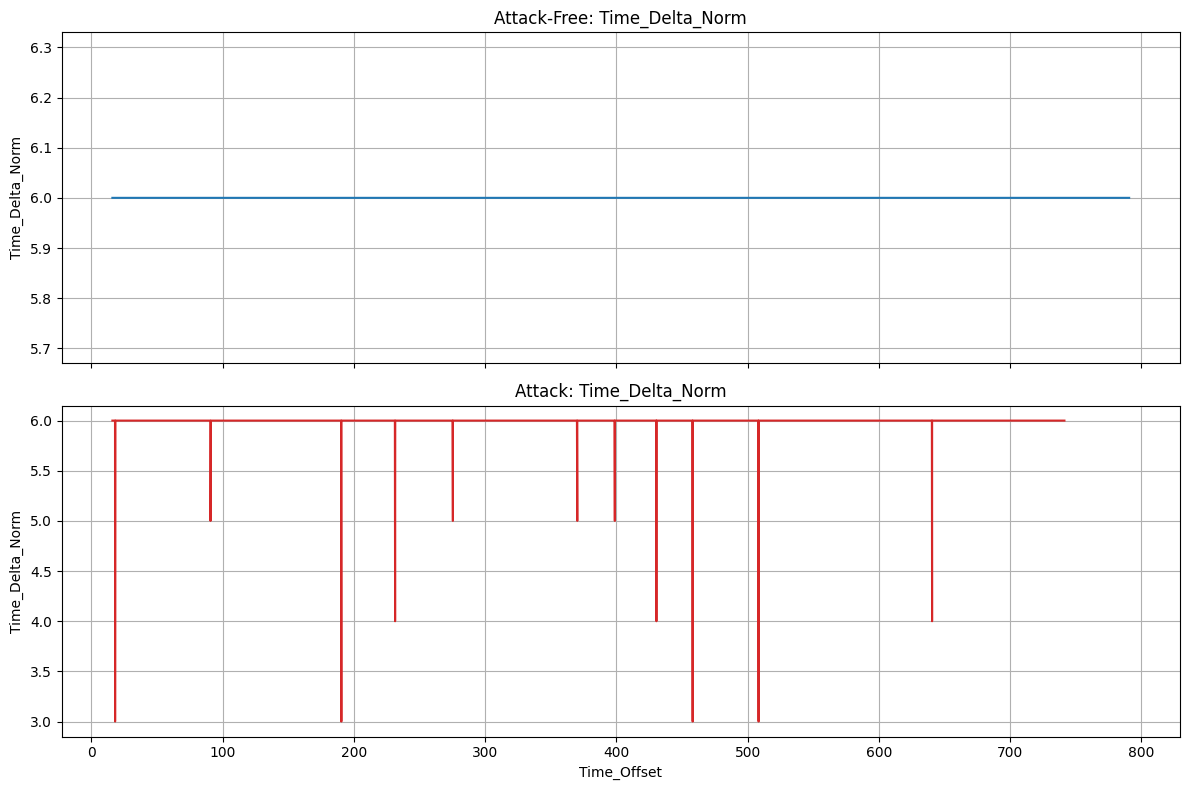

In [63]:
plot_can_id_comparison(Kia_AF, Kia_DoS_L, 'Time_Delta_Norm', 2000)

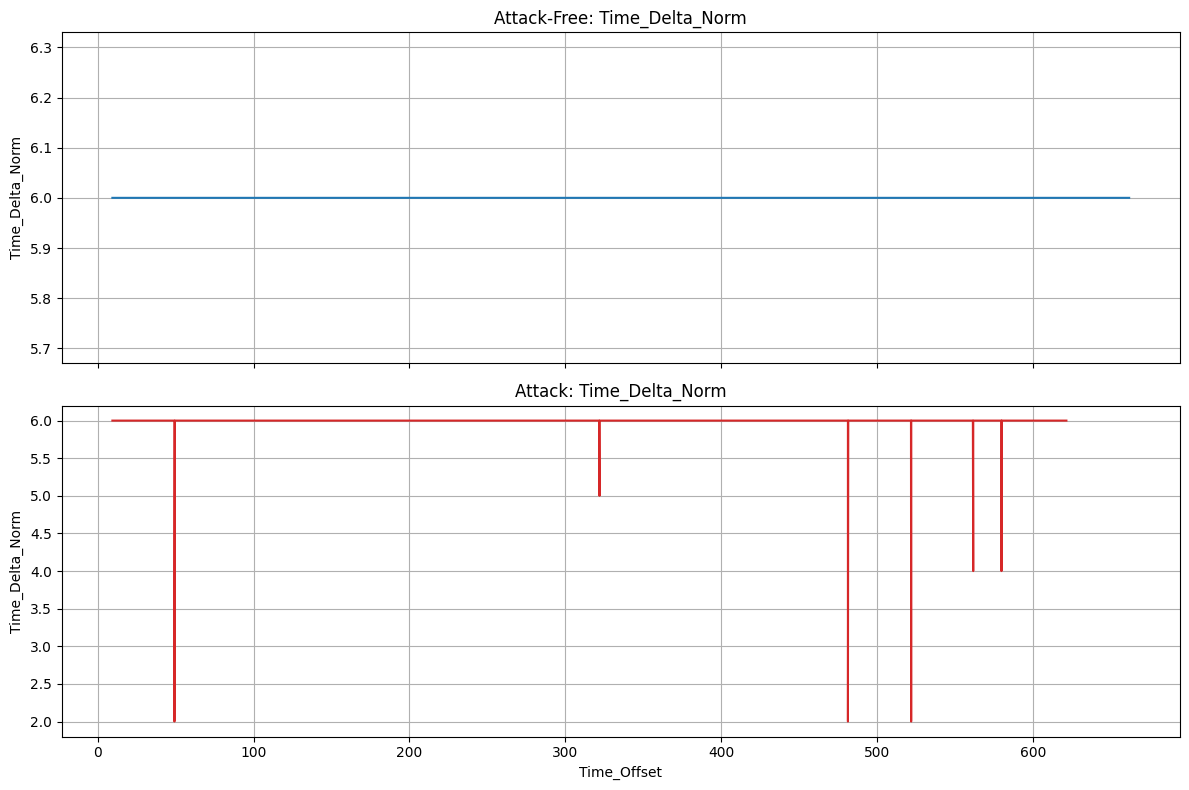

In [64]:
plot_can_id_comparison(Tesla_AF, Tesla_DoS_L, 'Time_Delta_Norm', 2000)

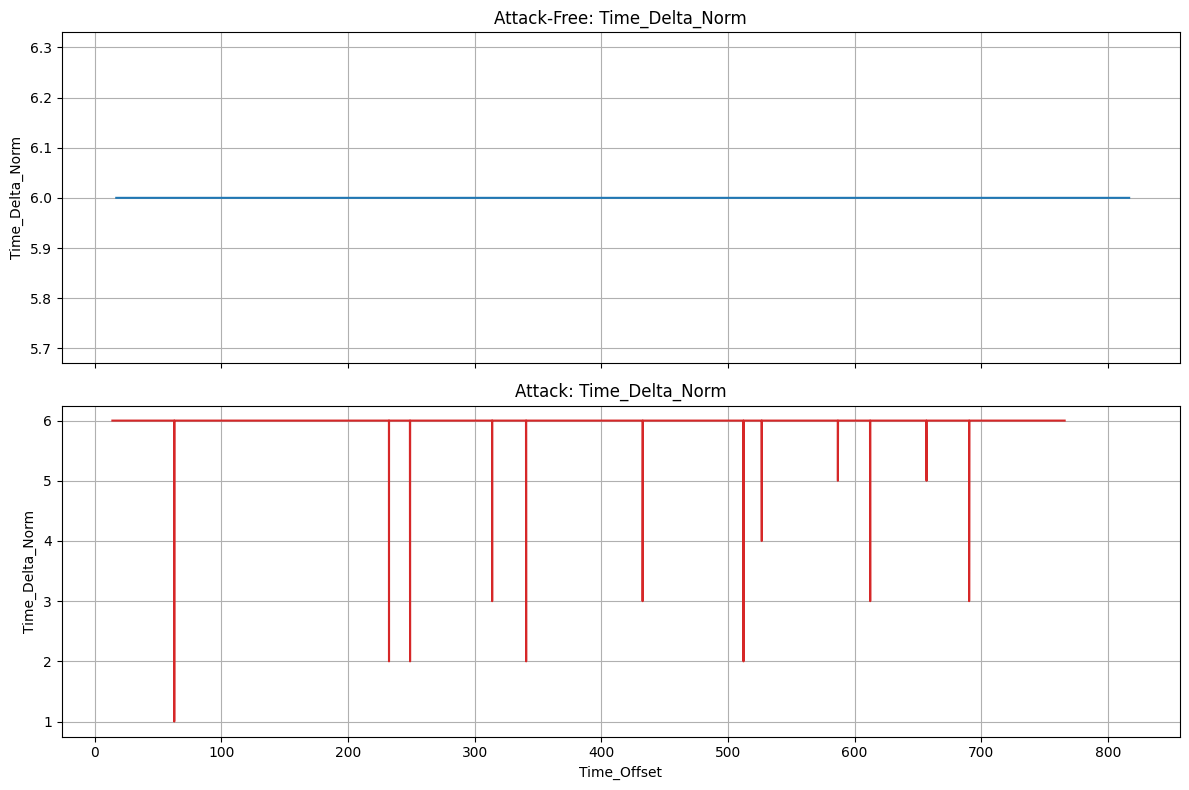

In [65]:
plot_can_id_comparison(Sil_AF, Sil_DoS_L, 'Time_Delta_Norm', 2000)

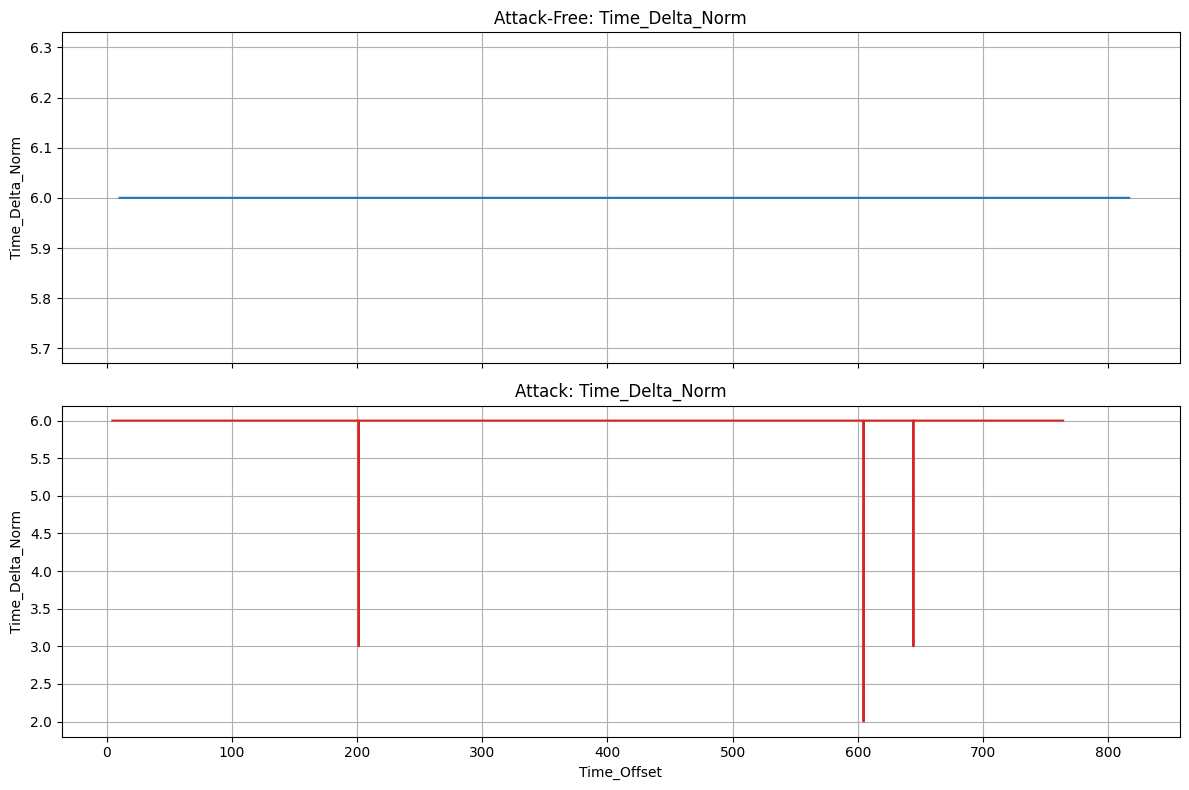

In [66]:
plot_can_id_comparison(Gen_AF, Gen_DoS_L, 'Time_Delta_Norm', 2000)

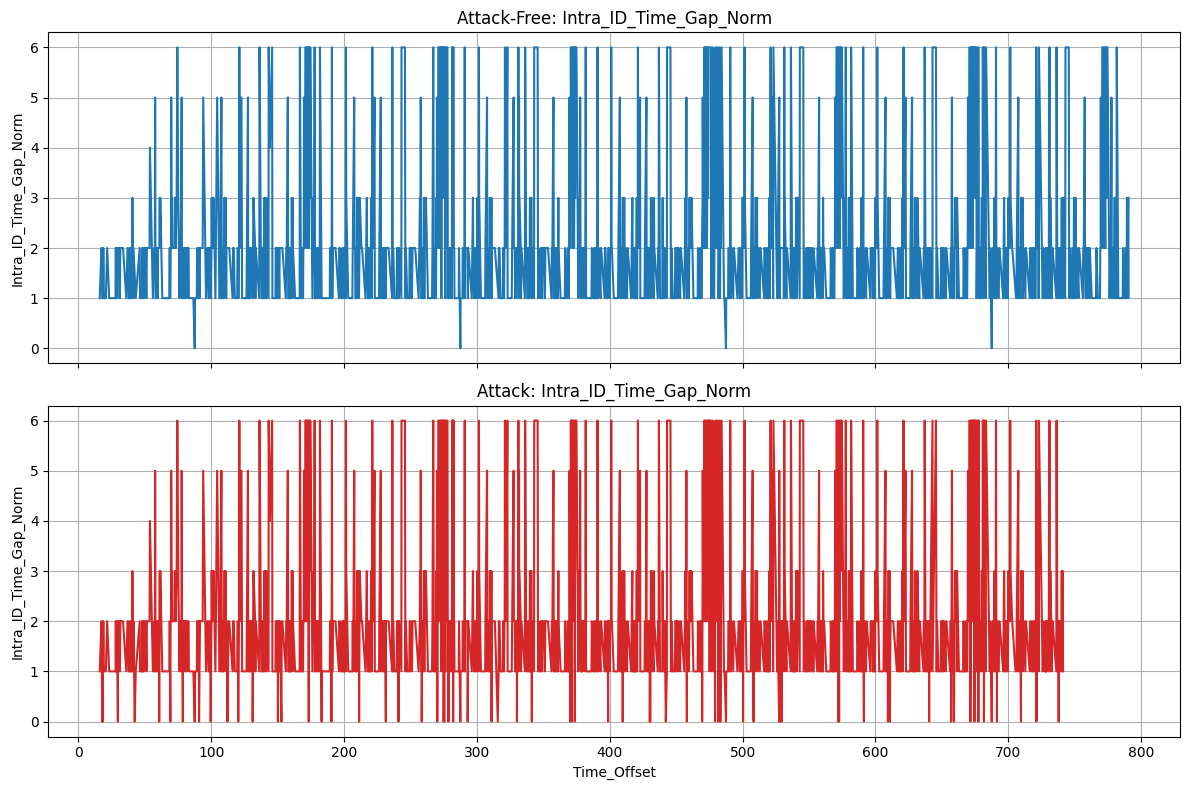

In [67]:
plot_can_id_comparison(Kia_AF, Kia_DoS_L, 'Intra_ID_Time_Gap_Norm', 2000)

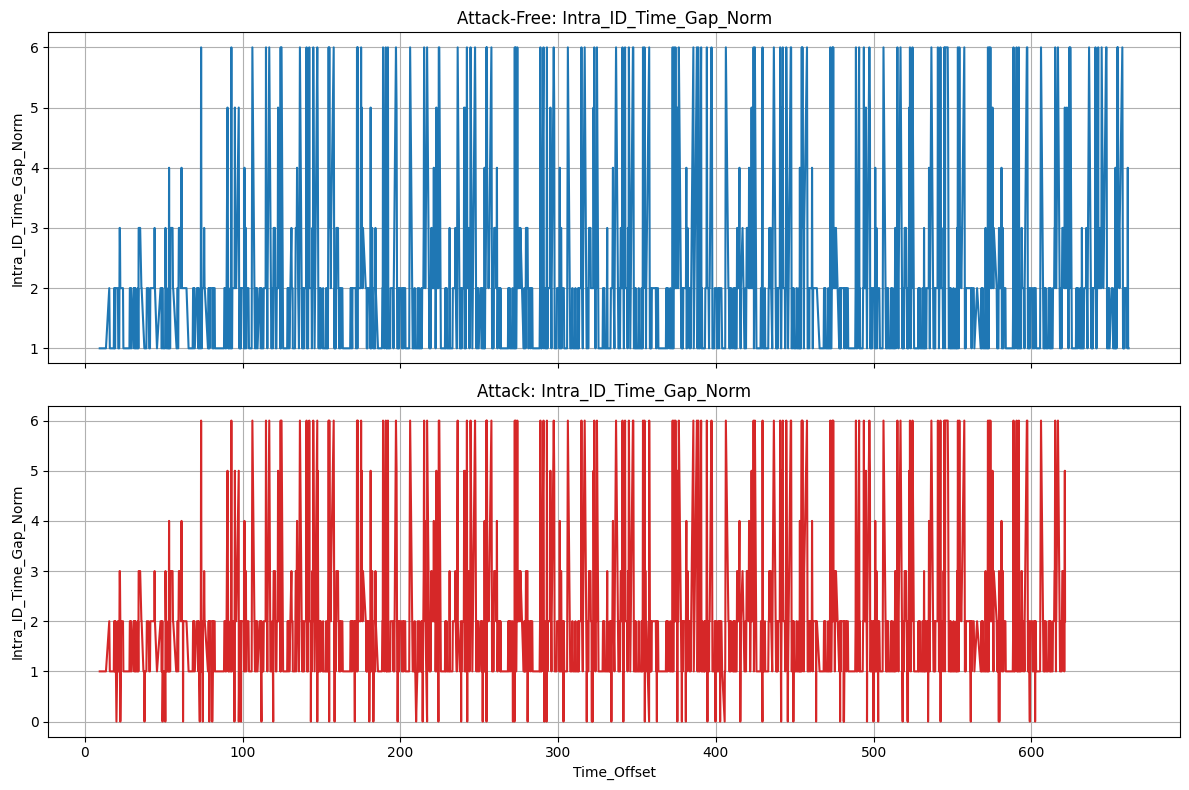

In [68]:
plot_can_id_comparison(Tesla_AF, Tesla_DoS_L, 'Intra_ID_Time_Gap_Norm', 2000)

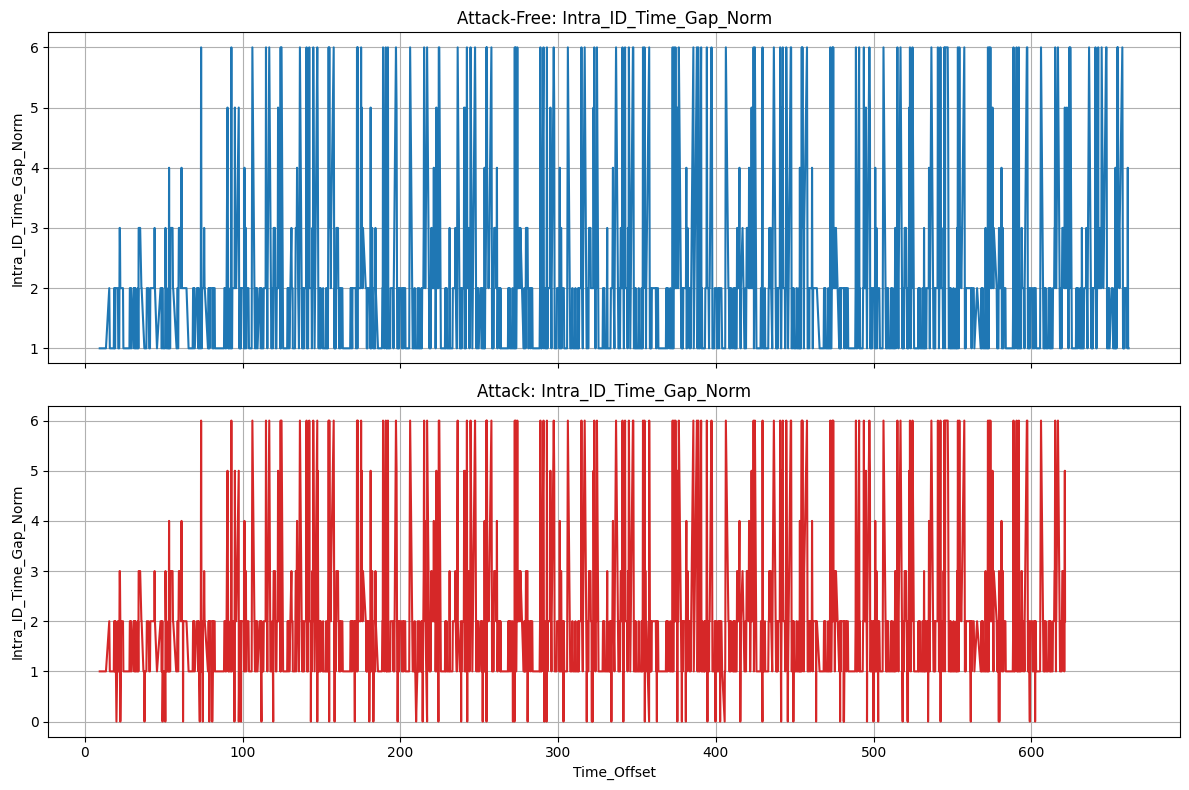

In [69]:
plot_can_id_comparison(Tesla_AF, Tesla_DoS_L, 'Intra_ID_Time_Gap_Norm', 2000)

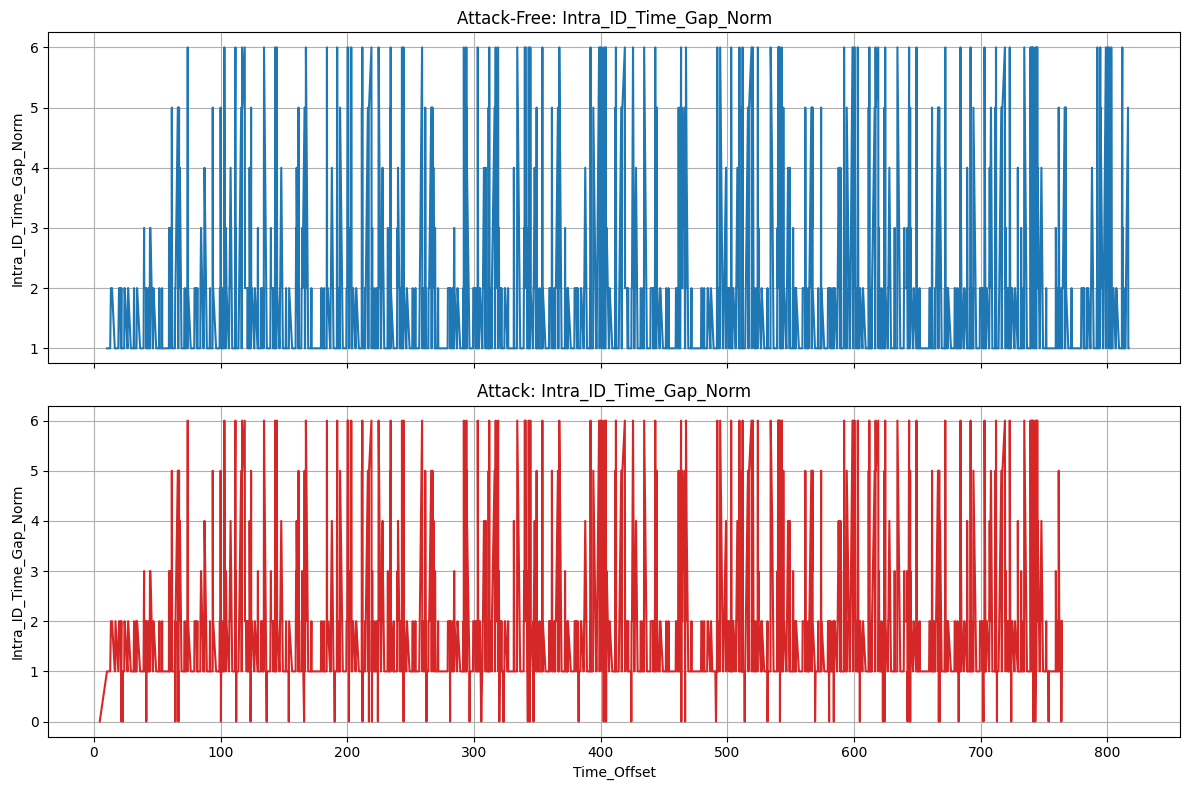

In [70]:
plot_can_id_comparison(Gen_AF, Gen_DoS_L, 'Intra_ID_Time_Gap_Norm', 2000)

In [74]:
Kia_DoS_M, Tesla_DoS_M, Sil_DoS_M, Gen_DoS_M = load_all_datasets("Kia_DoS_M.csv", "Tesla_DoS_M.csv", "Sil_DoS_M.csv", "Gen_DoS_M.csv")

/home/lisa/Arupreza/UIDS-II/AnalysisSrc/assets.py:17: DtypeWarning: Columns (20,22,23) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path + df)


✅ All DoS datasets loaded and preprocessed successfully.


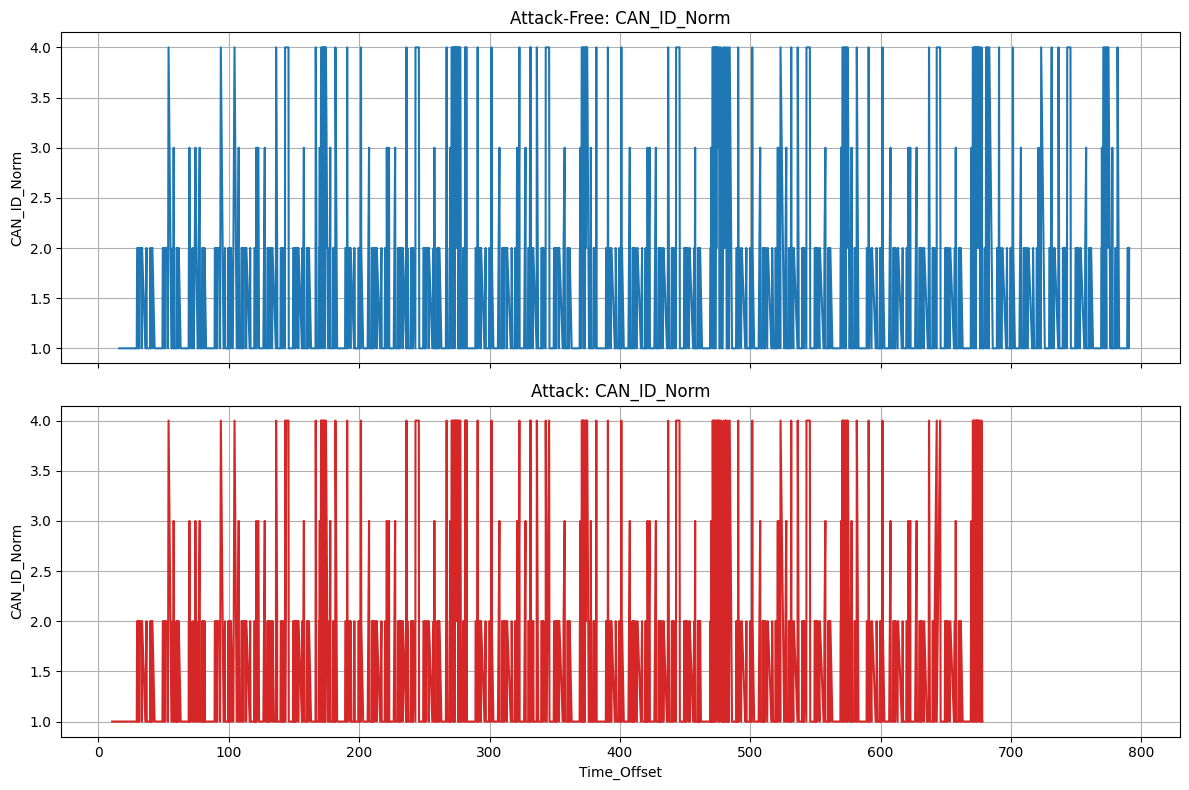

In [75]:
plot_can_id_comparison(Kia_AF, Kia_DoS_M, 'CAN_ID_Norm', 2000)

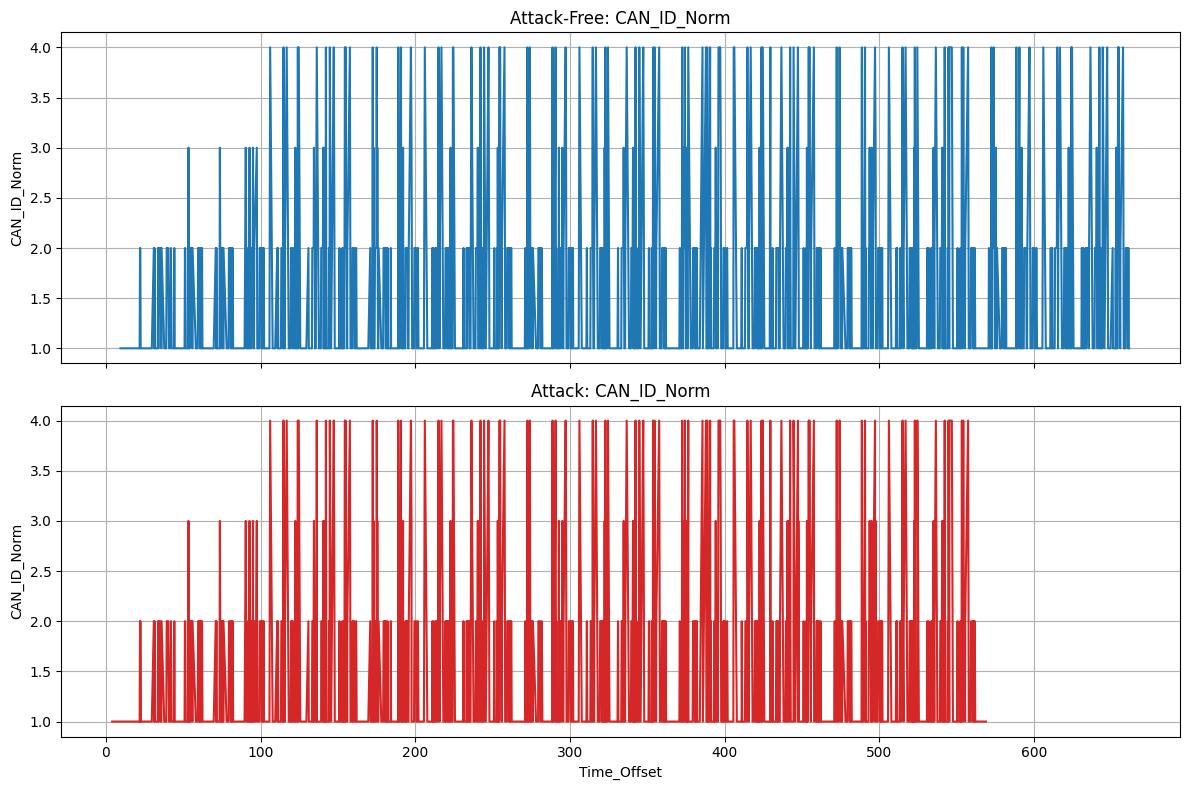

In [76]:
plot_can_id_comparison(Tesla_AF, Tesla_DoS_M, 'CAN_ID_Norm', 2000)

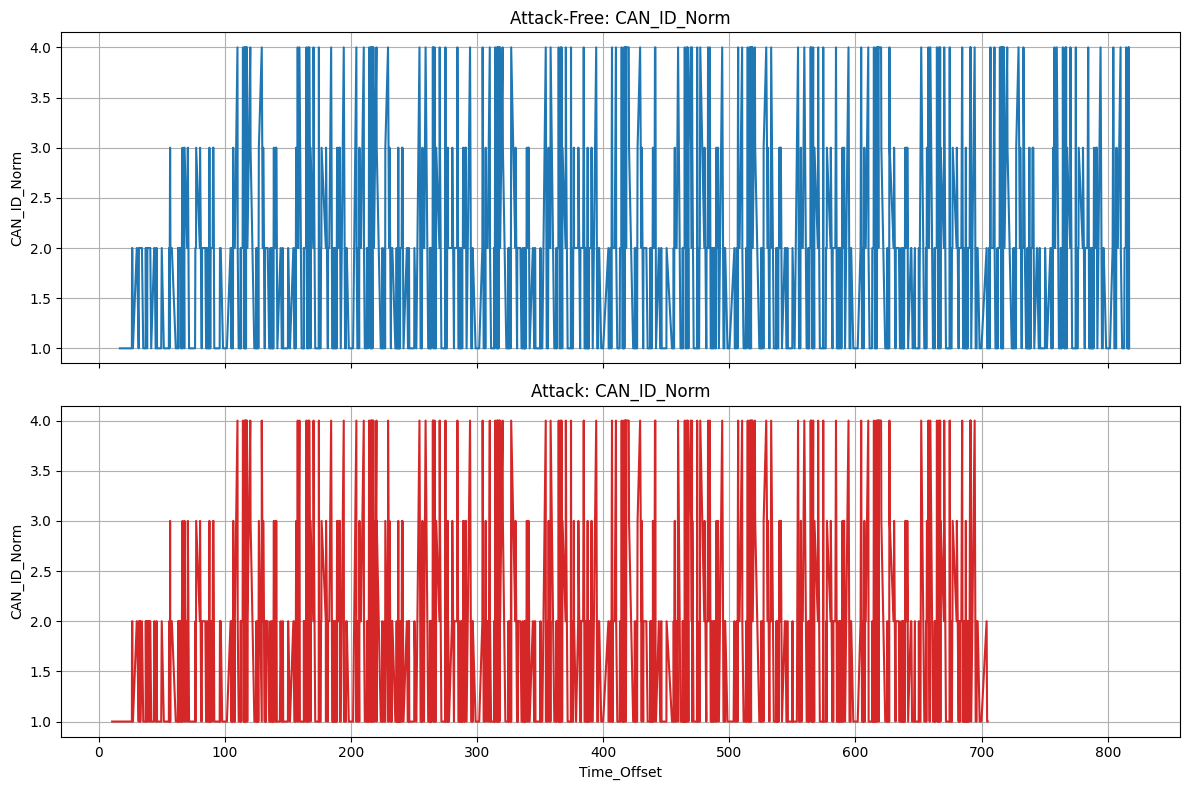

In [77]:
plot_can_id_comparison(Sil_AF, Sil_DoS_M, 'CAN_ID_Norm', 2000)

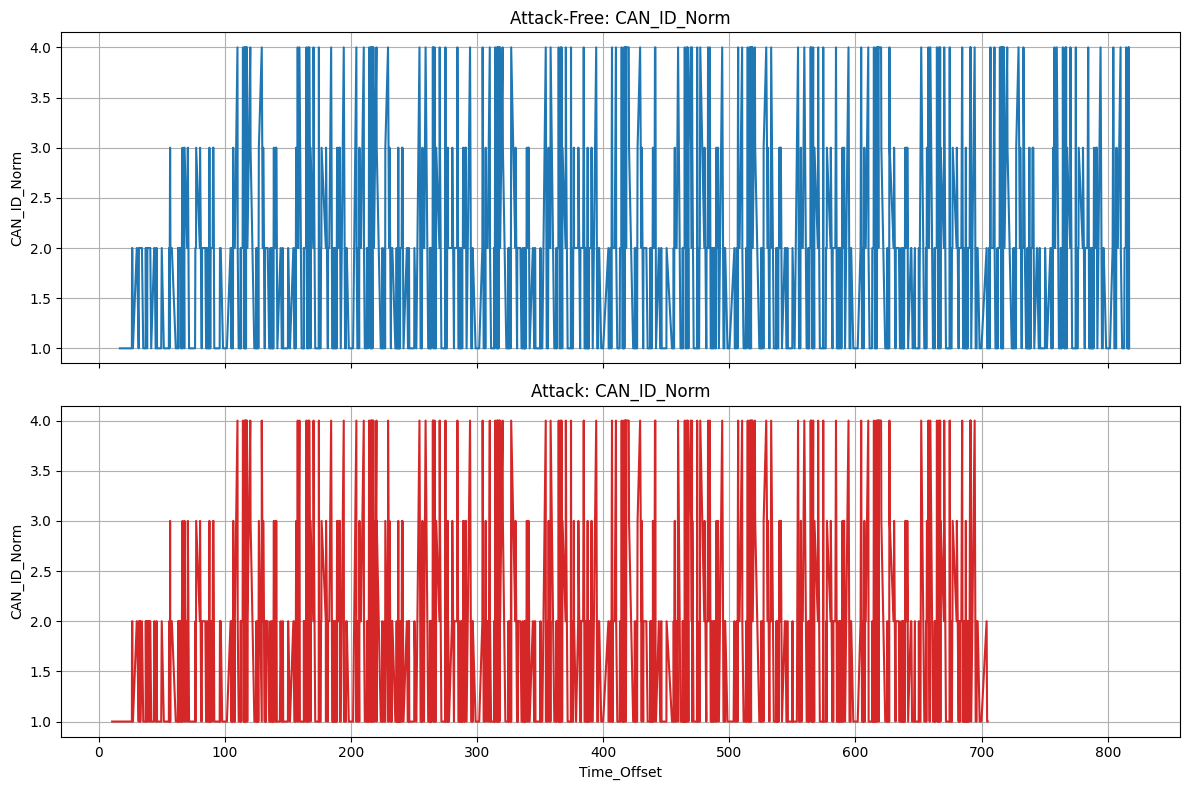

In [78]:
plot_can_id_comparison(Sil_AF, Sil_DoS_M, 'CAN_ID_Norm', 2000)

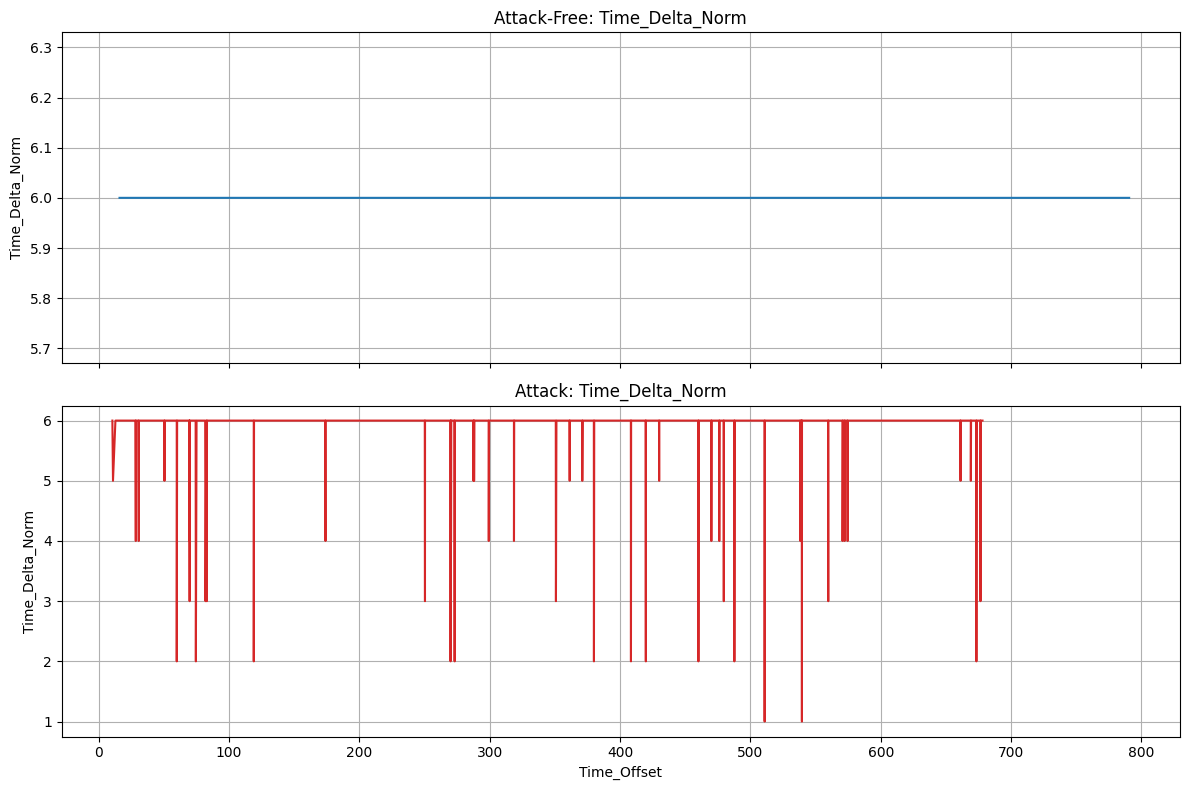

In [79]:
plot_can_id_comparison(Kia_AF, Kia_DoS_M, 'Time_Delta_Norm', 2000)

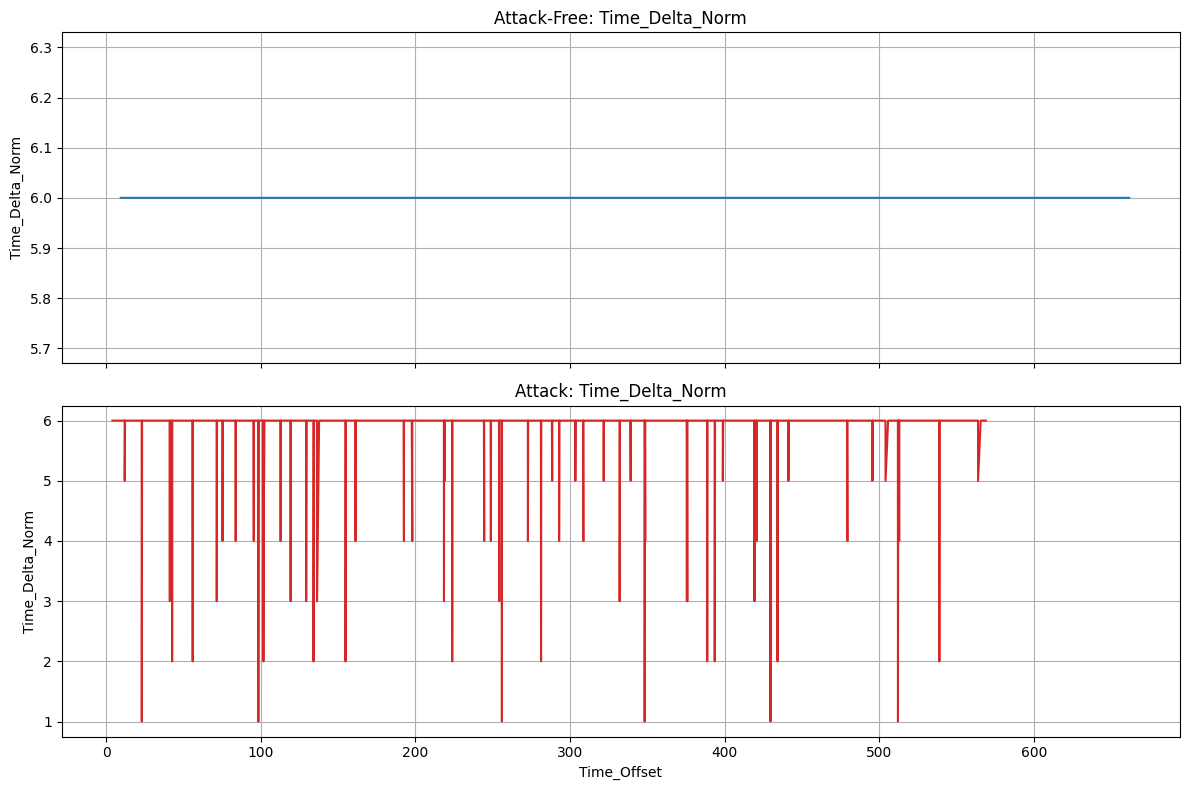

In [80]:
plot_can_id_comparison(Tesla_AF, Tesla_DoS_M, 'Time_Delta_Norm', 2000)

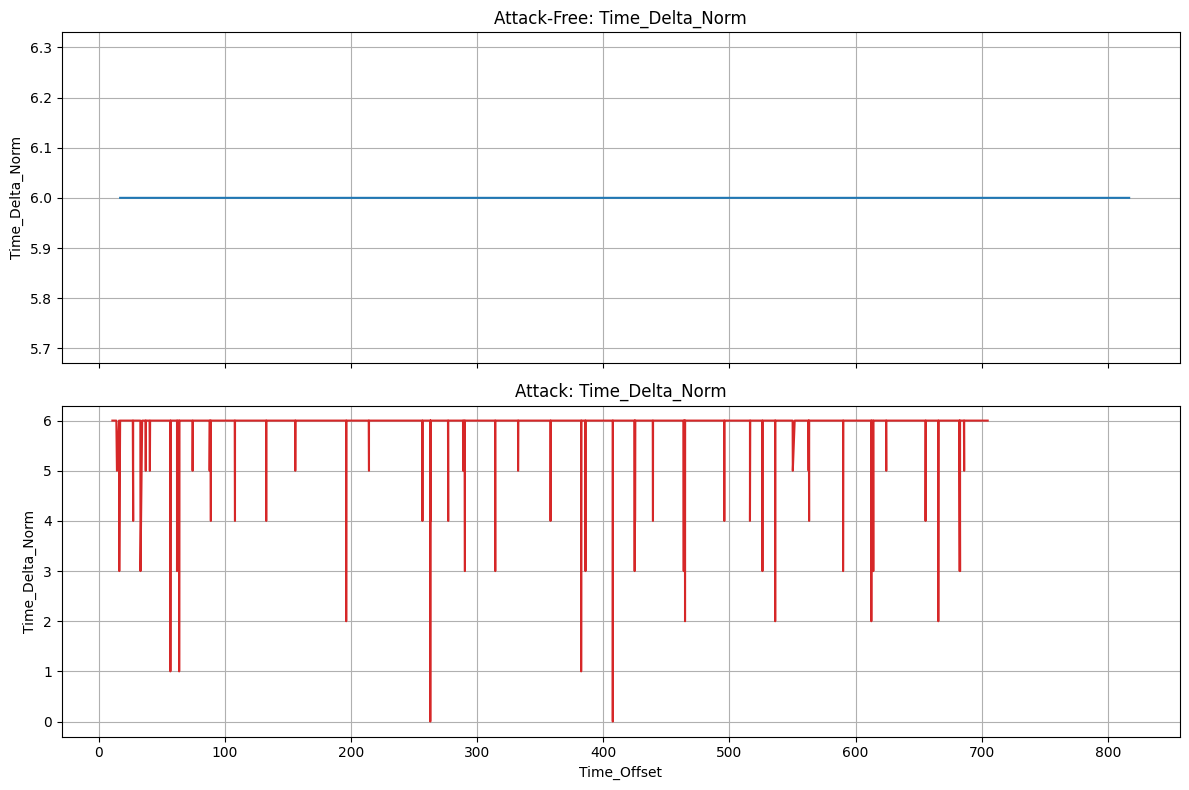

In [81]:
plot_can_id_comparison(Sil_AF, Sil_DoS_M, 'Time_Delta_Norm', 2000)

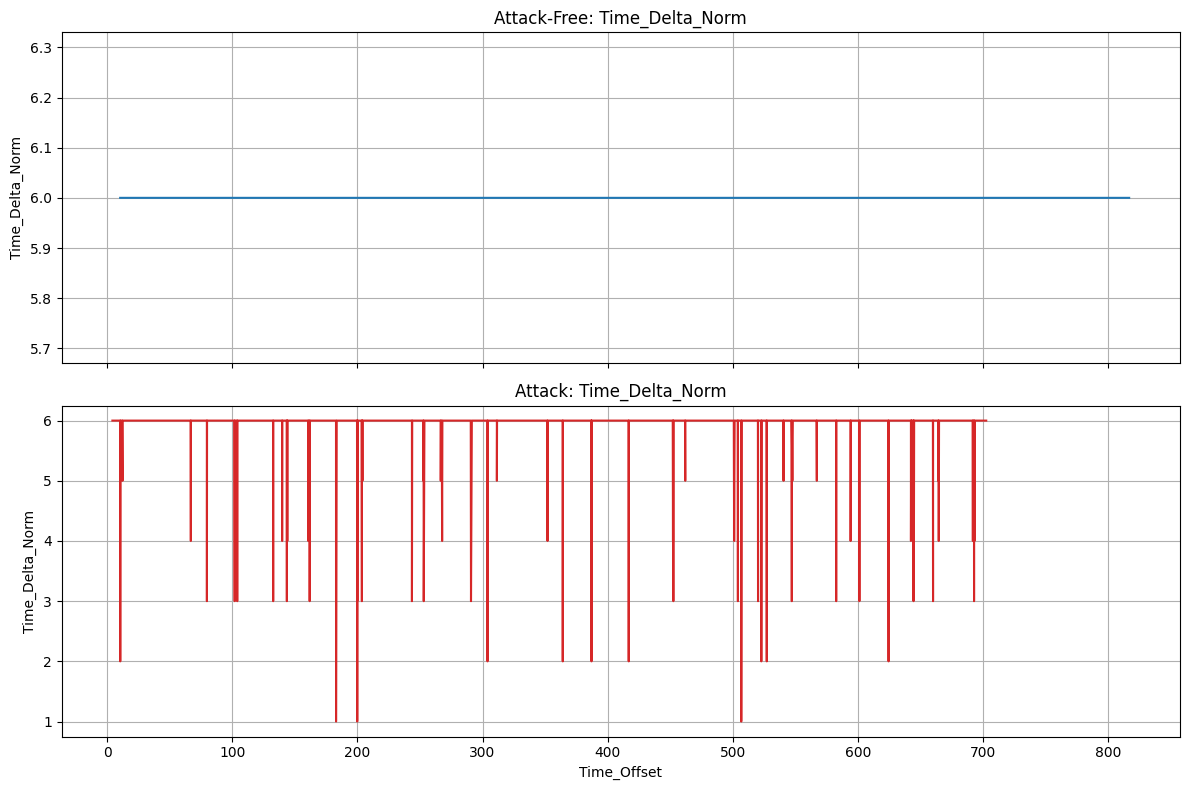

In [82]:
plot_can_id_comparison(Gen_AF, Gen_DoS_M, 'Time_Delta_Norm', 2000)

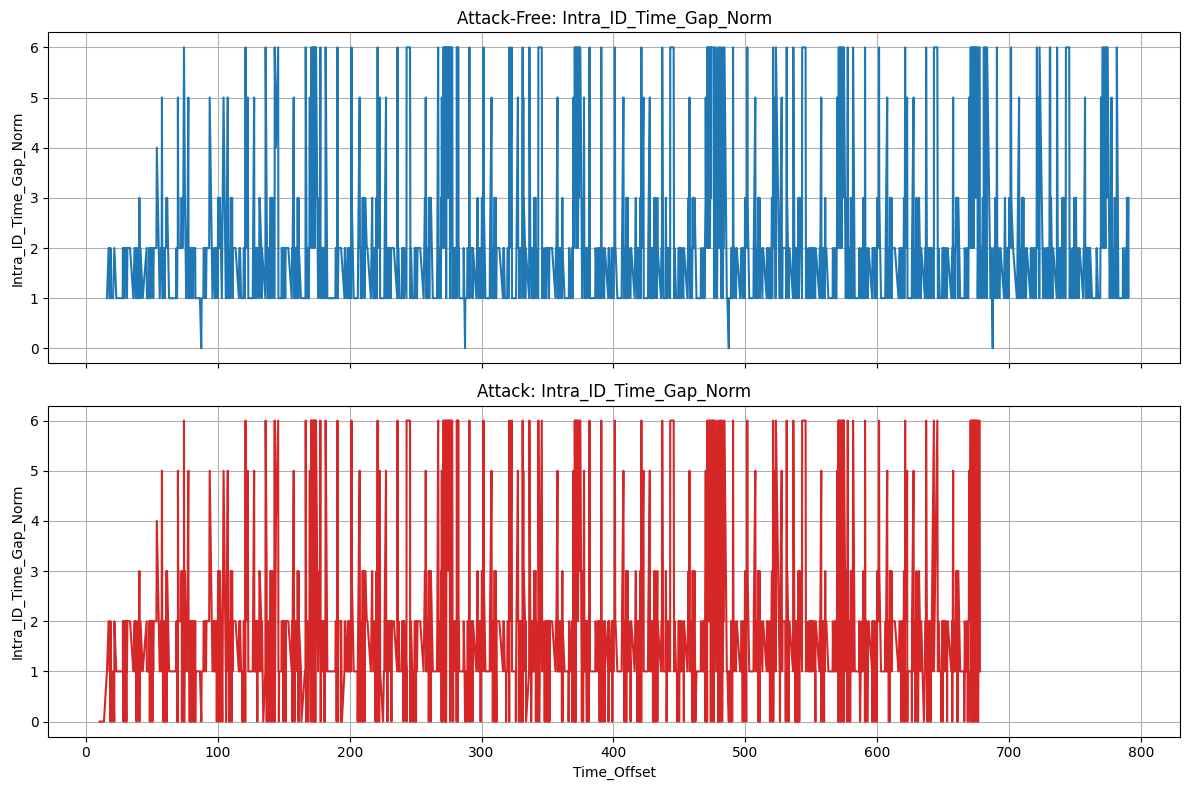

In [83]:
plot_can_id_comparison(Kia_AF, Kia_DoS_M, 'Intra_ID_Time_Gap_Norm', 2000)

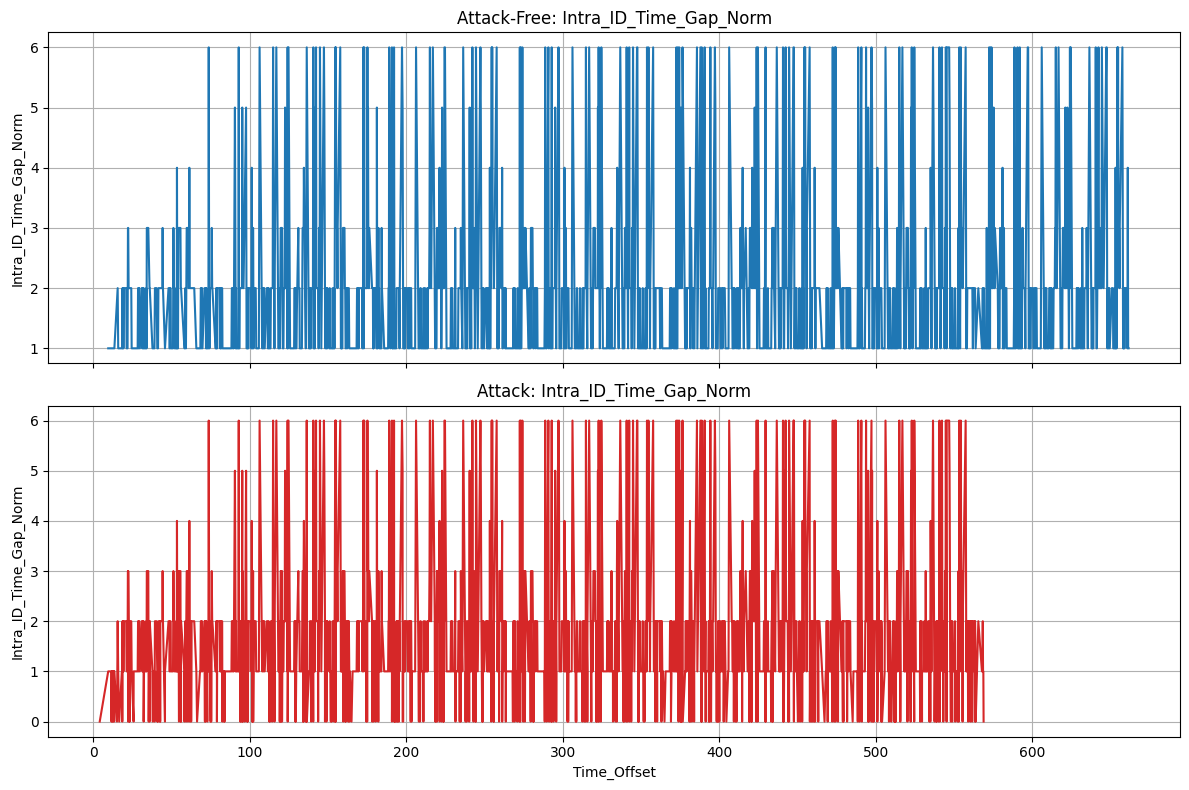

In [84]:
plot_can_id_comparison(Tesla_AF, Tesla_DoS_M, 'Intra_ID_Time_Gap_Norm', 2000)

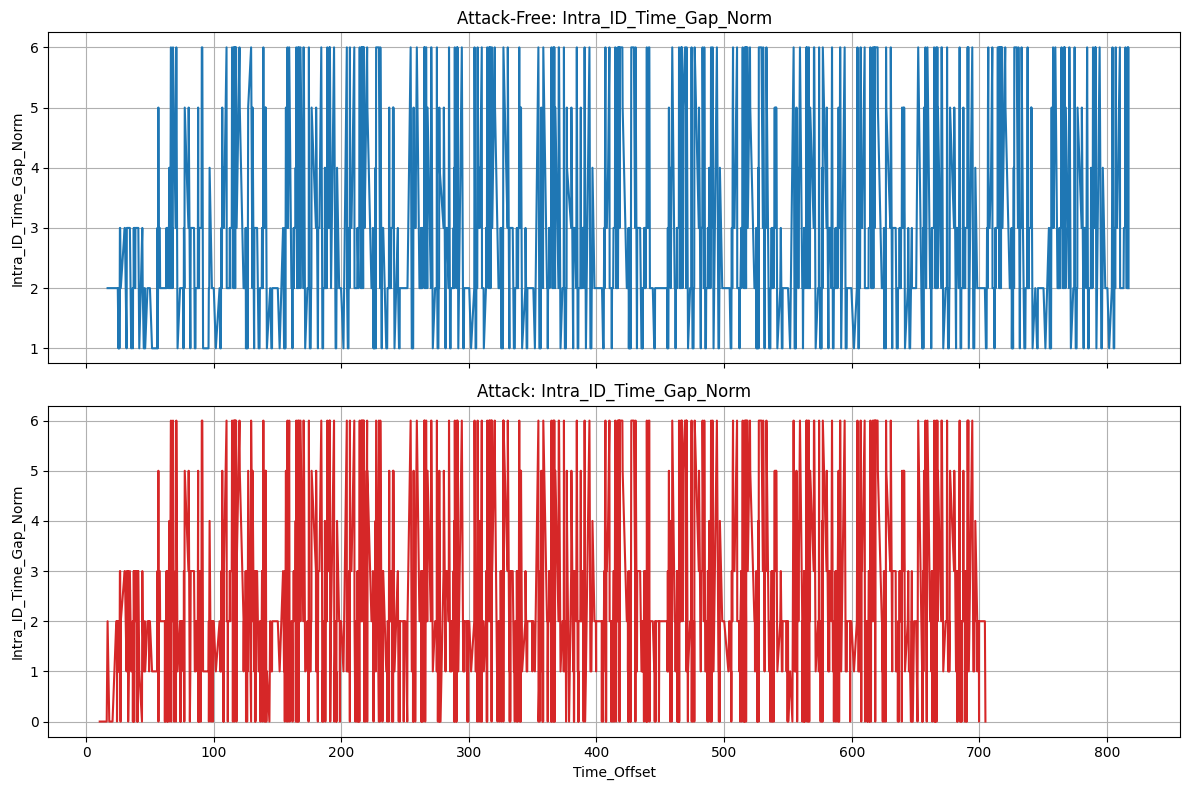

In [85]:
plot_can_id_comparison(Sil_AF, Sil_DoS_M, 'Intra_ID_Time_Gap_Norm', 2000)

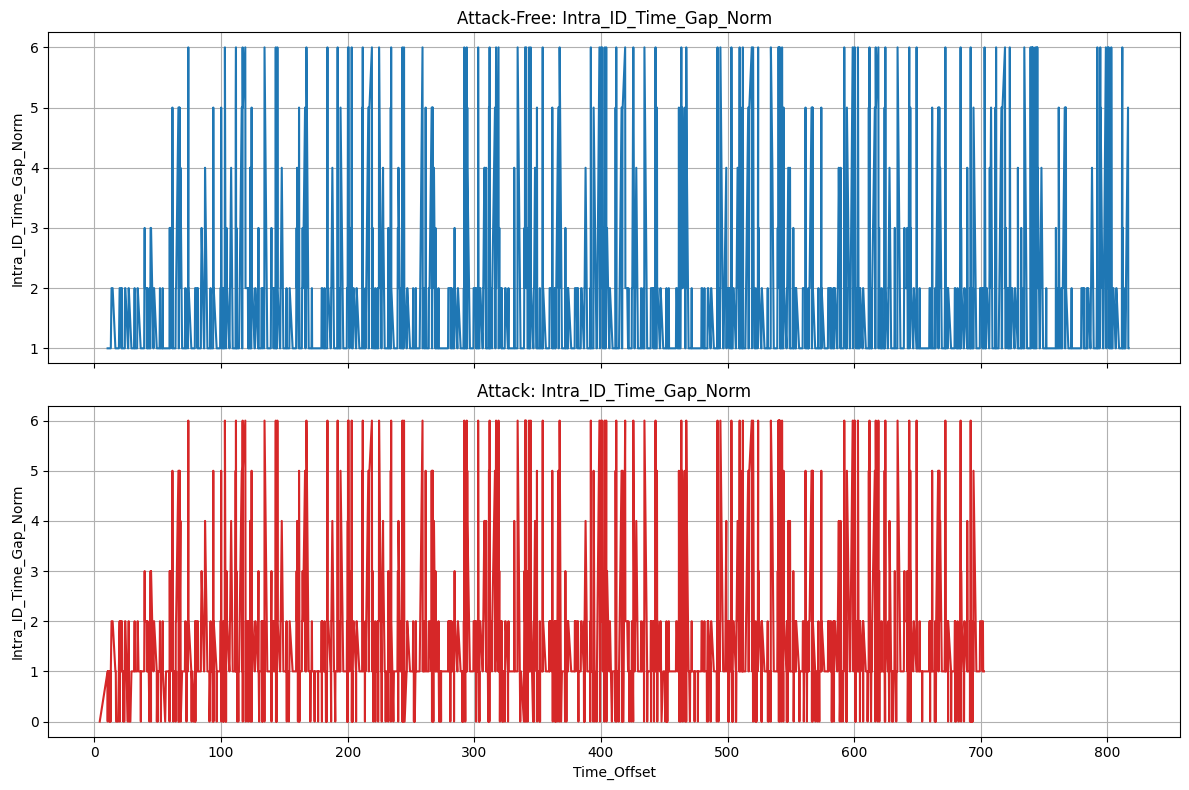

In [86]:
plot_can_id_comparison(Gen_AF, Gen_DoS_M, 'Intra_ID_Time_Gap_Norm', 2000)

In [87]:
Kia_DoS_H, Tesla_DoS_H, Sil_DoS_H, Gen_DoS_H = load_all_datasets("Kia_DoS_H.csv", "Tesla_DoS_H.csv", "Sil_DoS_H.csv", "Gen_DoS_H.csv")

/home/lisa/Arupreza/UIDS-II/AnalysisSrc/assets.py:17: DtypeWarning: Columns (20,22,23) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path + df)


✅ All DoS datasets loaded and preprocessed successfully.


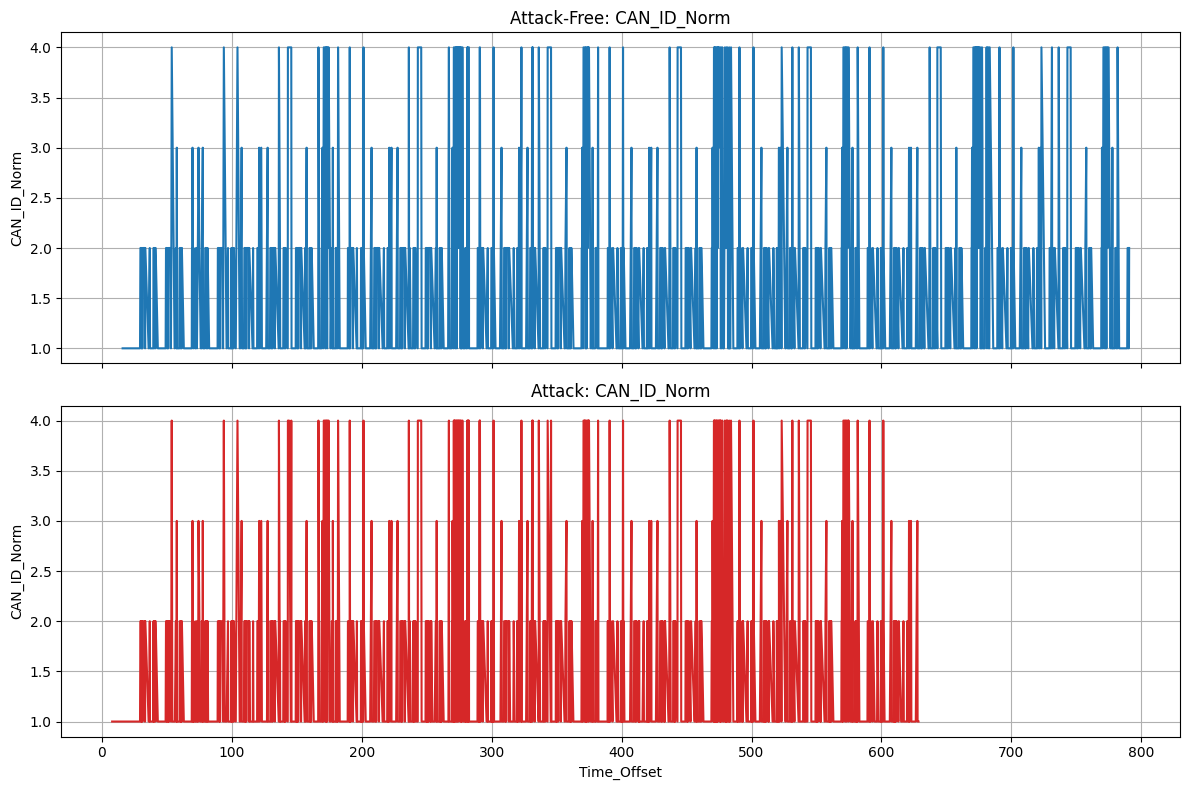

In [88]:
plot_can_id_comparison(Kia_AF, Kia_DoS_H, 'CAN_ID_Norm', 2000)

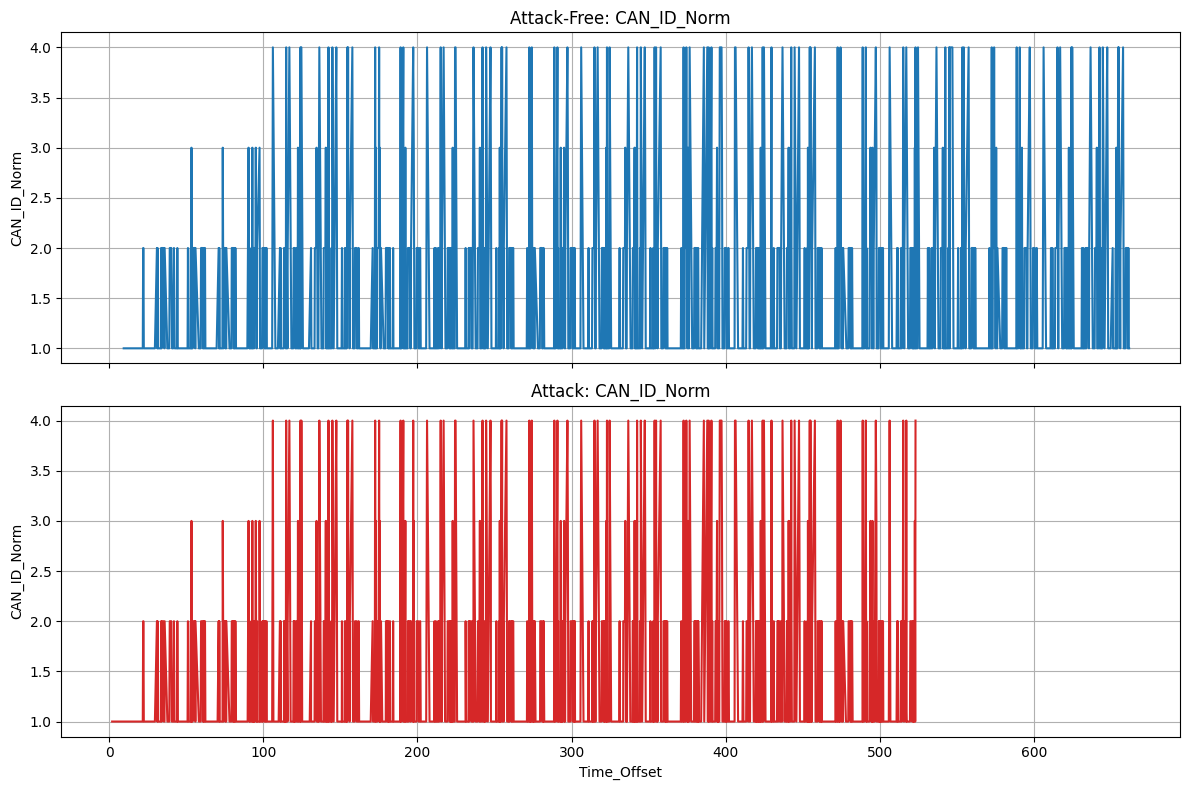

In [89]:
plot_can_id_comparison(Tesla_AF, Tesla_DoS_H, 'CAN_ID_Norm', 2000)

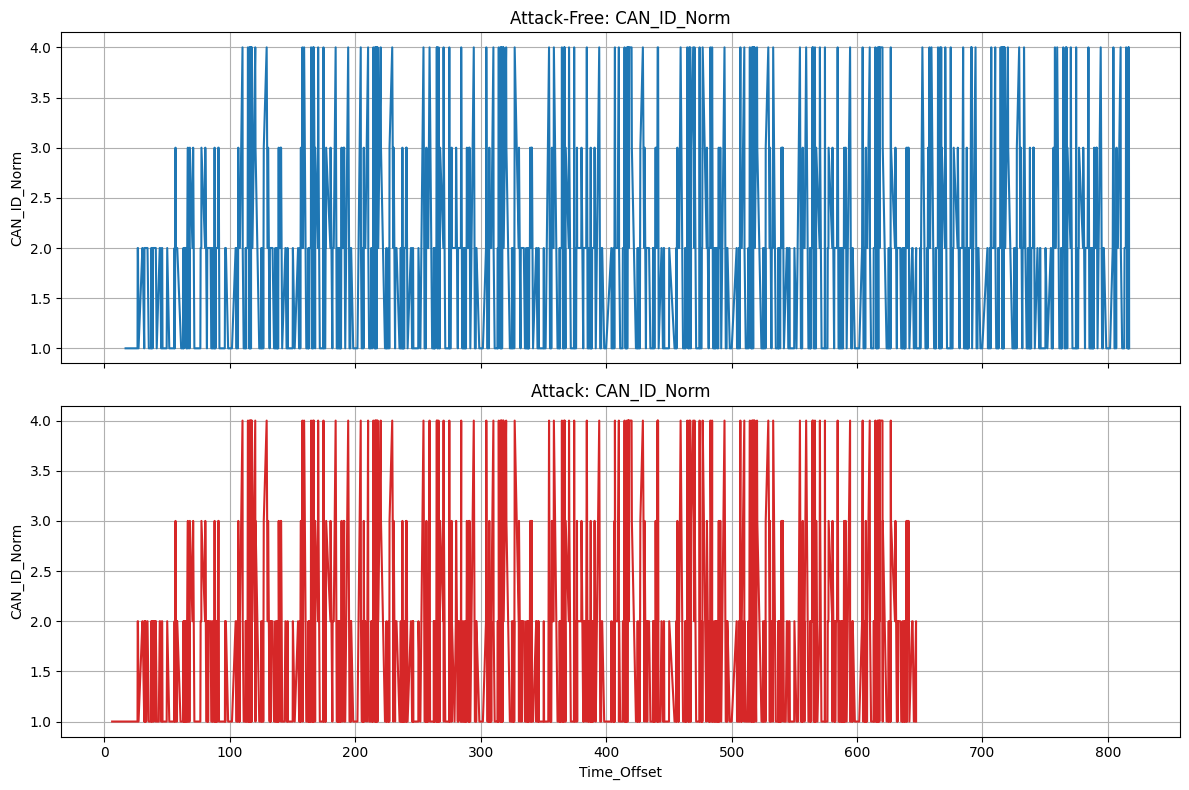

In [90]:
plot_can_id_comparison(Sil_AF, Sil_DoS_H, 'CAN_ID_Norm', 2000)

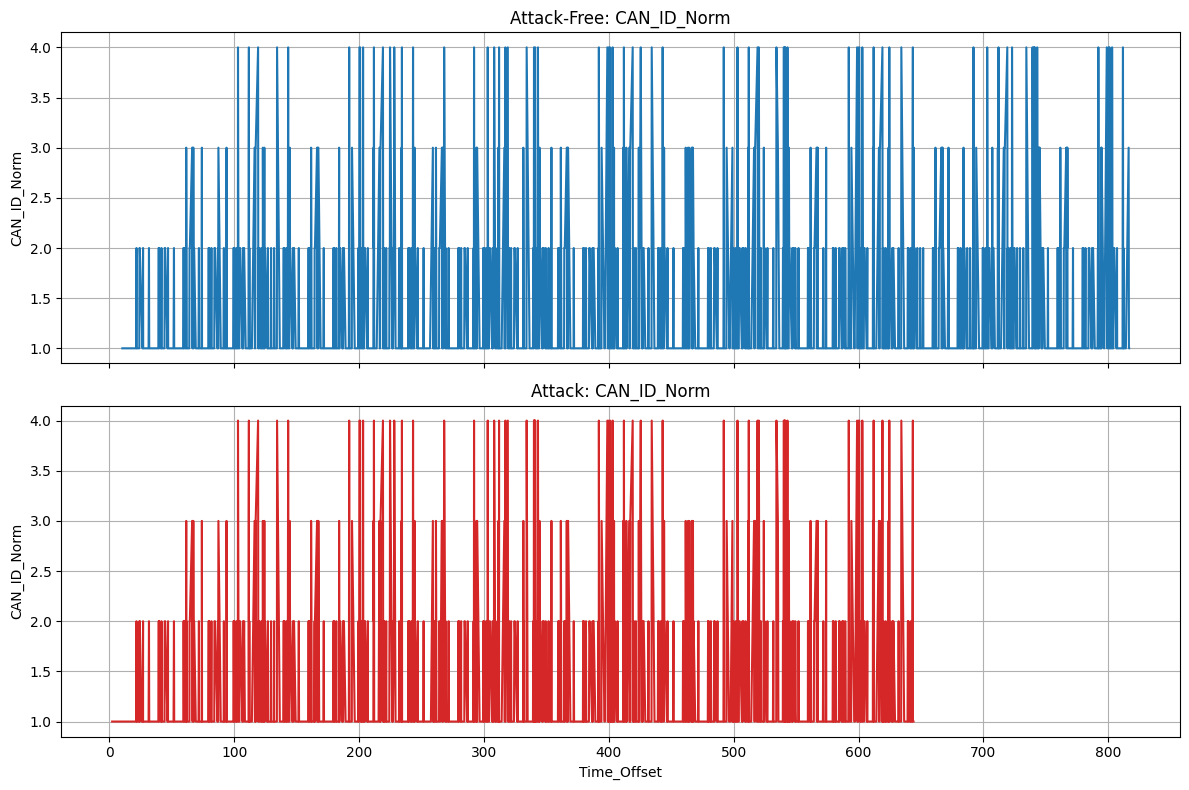

In [91]:
plot_can_id_comparison(Gen_AF, Gen_DoS_H, 'CAN_ID_Norm', 2000)

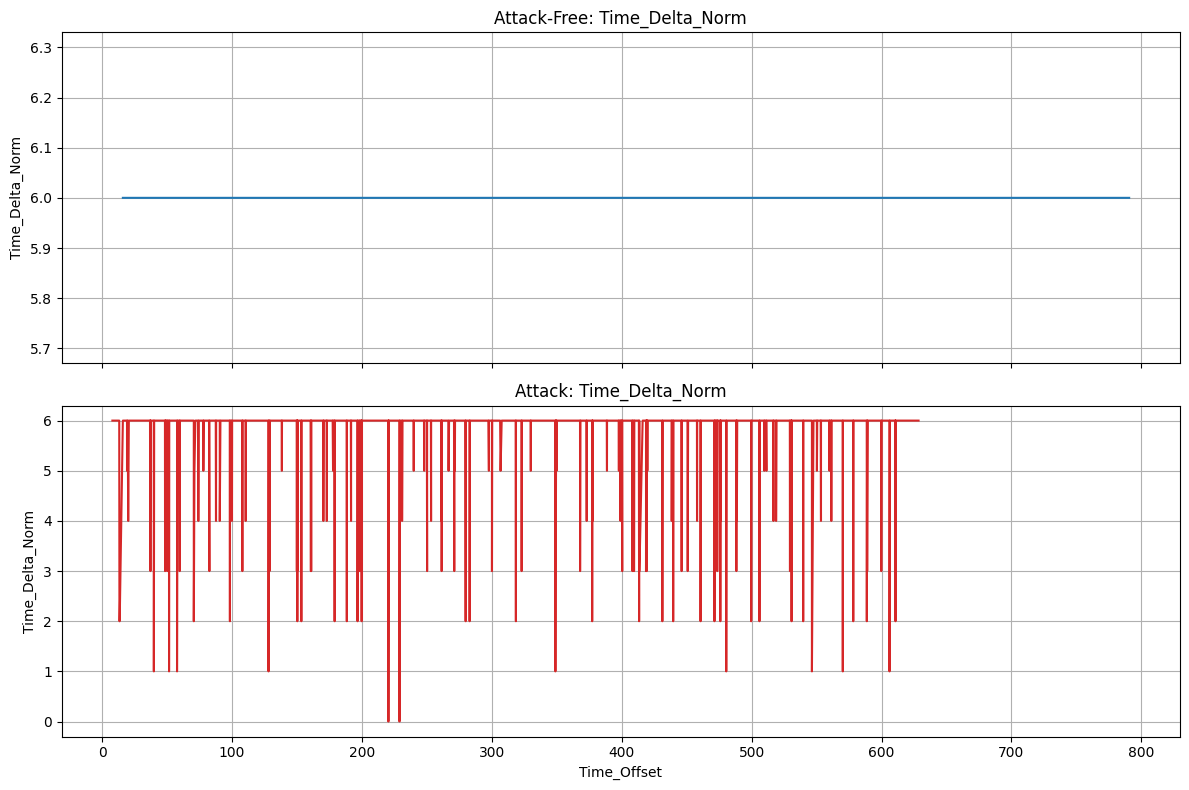

In [92]:
plot_can_id_comparison(Kia_AF, Kia_DoS_H, 'Time_Delta_Norm', 2000)

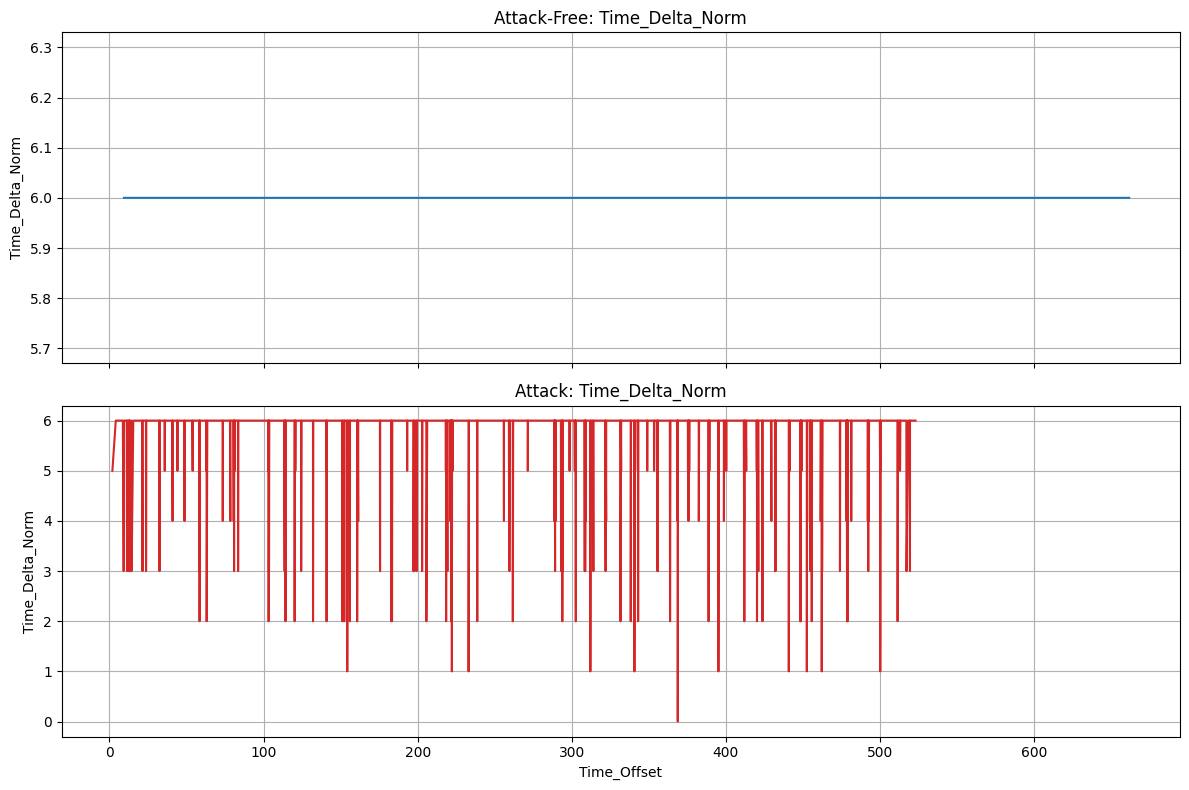

In [93]:
plot_can_id_comparison(Tesla_AF, Tesla_DoS_H, 'Time_Delta_Norm', 2000)

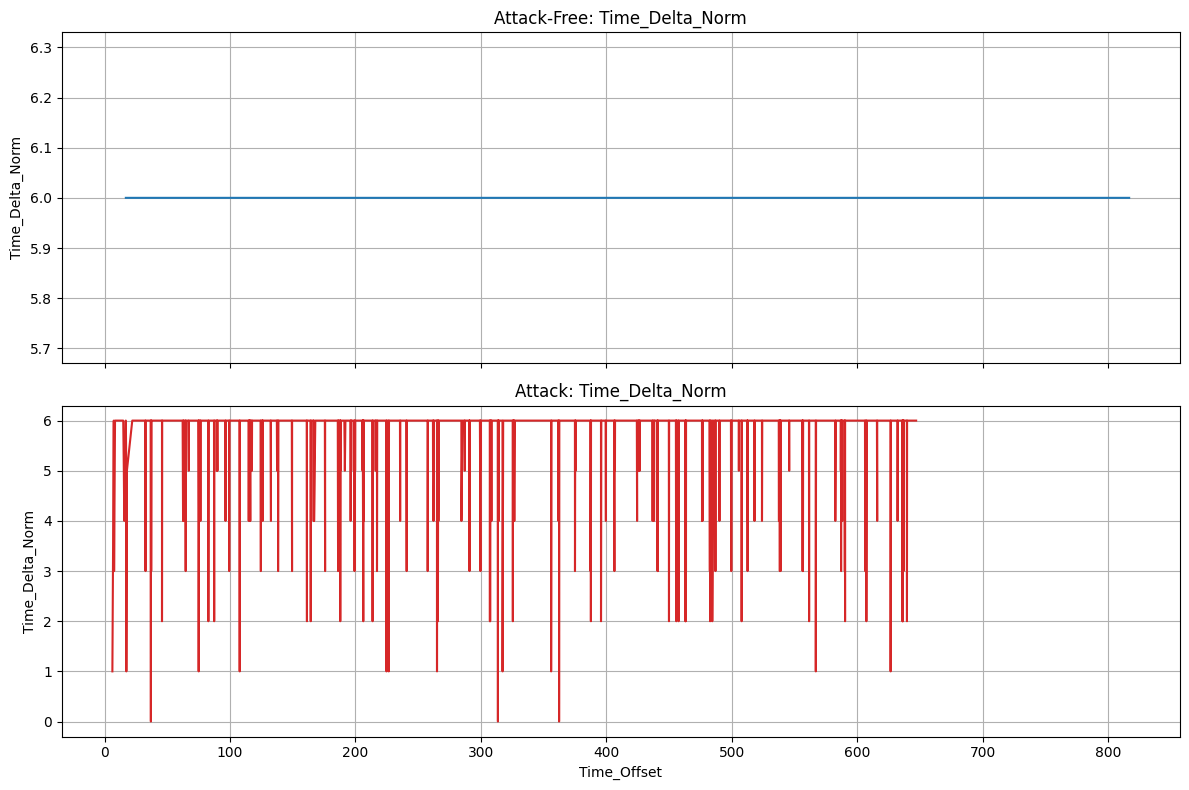

In [94]:
plot_can_id_comparison(Sil_AF, Sil_DoS_H, 'Time_Delta_Norm', 2000)

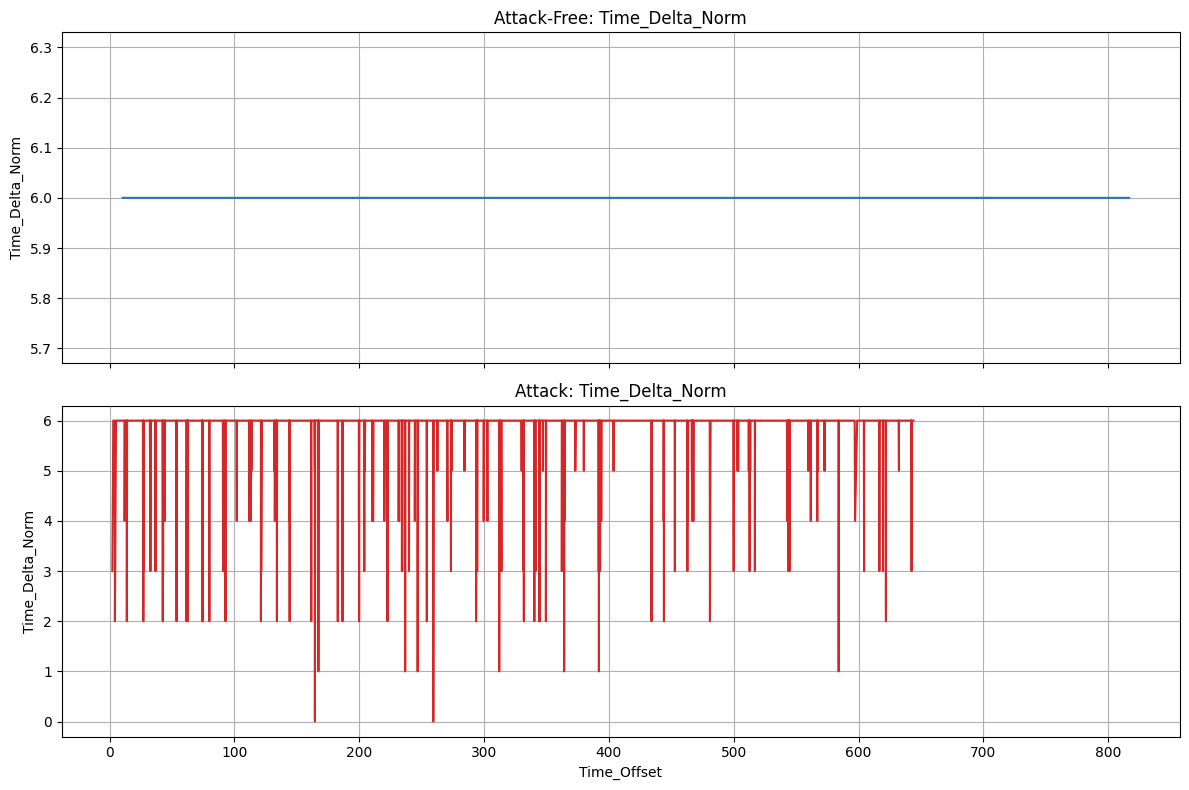

In [95]:
plot_can_id_comparison(Gen_AF, Gen_DoS_H, 'Time_Delta_Norm', 2000)

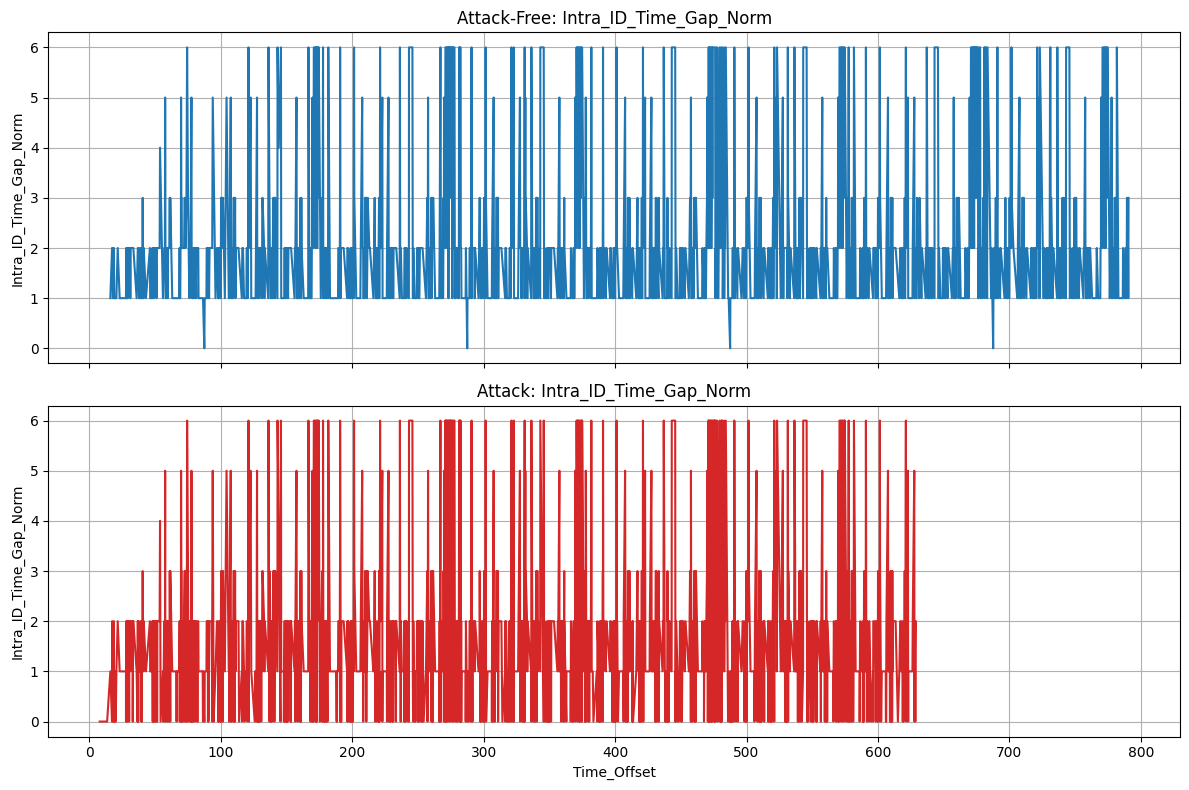

In [96]:
plot_can_id_comparison(Kia_AF, Kia_DoS_H, 'Intra_ID_Time_Gap_Norm', 2000)

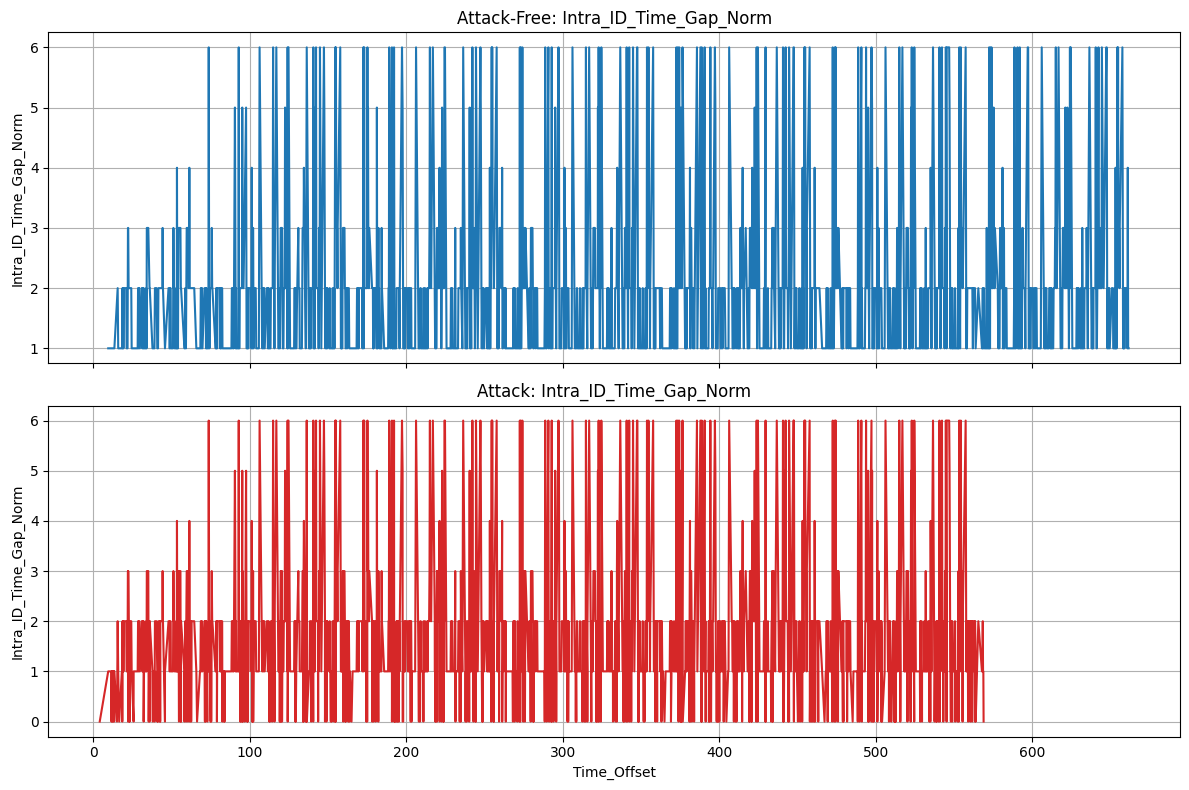

In [97]:
plot_can_id_comparison(Tesla_AF, Tesla_DoS_M, 'Intra_ID_Time_Gap_Norm', 2000)

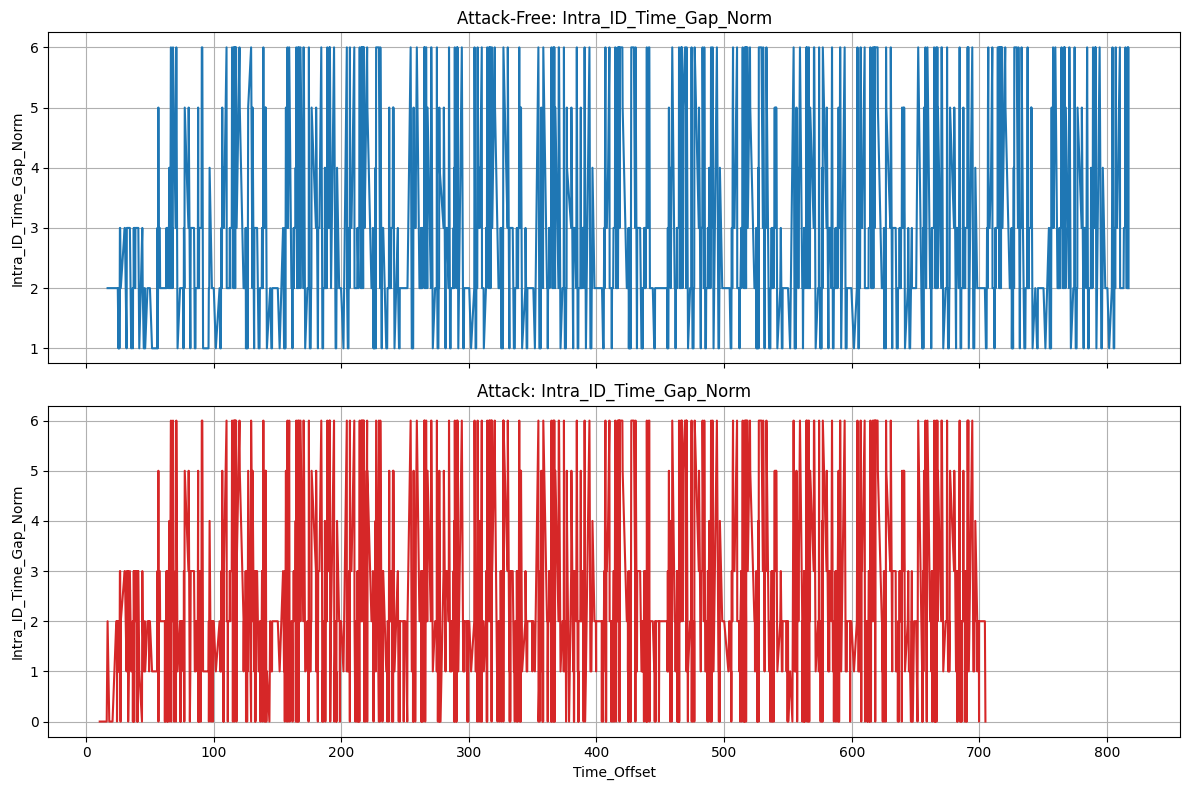

In [98]:
plot_can_id_comparison(Sil_AF, Sil_DoS_M, 'Intra_ID_Time_Gap_Norm', 2000)

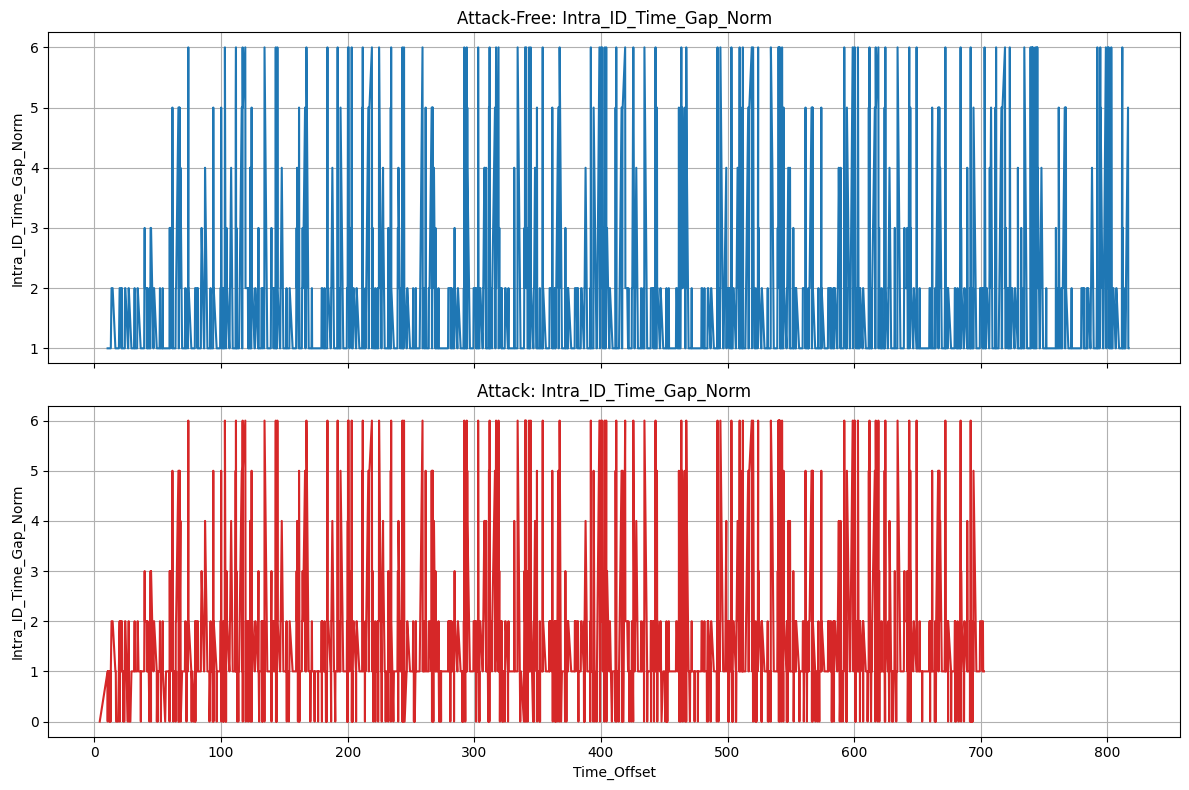

In [99]:
plot_can_id_comparison(Gen_AF, Gen_DoS_M, 'Intra_ID_Time_Gap_Norm', 2000)

In [4]:
def distribution(col, low, up):
    def value_count(df):
        # 1. Calculate value counts correctly.
        time_gap_counts = df[col].value_counts()

        # 2. Convert the Series to a DataFrame and reset the index.
        counts_df = time_gap_counts.reset_index()

        # 3. Rename the columns for clarity and proper structure.
        counts_df.columns = [col, 'Count']
        
        return counts_df
    
    Kia_AF_dis = value_count(Kia_AF)
    Tesla_AF_dis = value_count(Tesla_AF)
    Gen_AF_dis = value_count(Gen_AF)
    Sil_AF_dis = value_count(Sil_AF)
    
    print(f"Kia {col}: ", Kia_AF_dis[Kia_AF_dis[col].between(low, up)]['Count'].sum())
    print(f"Tesla {col}: ", Tesla_AF_dis[Tesla_AF_dis[col].between(low, up)]['Count'].sum())
    print(f"Gennesis {col}: ", Gen_AF_dis[Gen_AF_dis[col].between(low, up)]['Count'].sum())
    print(f"Silvarado {col}: ", Sil_AF_dis[Sil_AF_dis[col].between(low, up)]['Count'].sum())
    
    return None

,Time_Offset,CAN_ID_Norm,Time_Delta,Intra_ID_Time_Gap,CAN_ID_Norm_Time_Delta,Time_Delta_Norm,Intra_ID_Time_Gap_Norm,Label
0,16.0,1,2.1,10.0,2.7,6,1,Normal
1,17.3,1,0.2,11.0,1.3,6,2,Normal
2,17.5,1,0.2,11.1,0.2,6,2,Normal
3,17.9,1,0.4,9.8,0.4,6,1,Normal
4,18.0,1,0.1,9.5,0.1,6,1,Normal
...,...,...,...,...,...,...,...,...
599916,228123.8,1,0.2,9.3,0.2,6,1,Normal
599917,228124.0,1,0.2,10.6,0.2,6,2,Normal
599918,228124.2,1,0.2,10.3,0.2,6,2,Normal
599919,228124.5,3,0.3,50.6,4.8,6,6,Normal


Intra_ID_Time_Gap

In [242]:
distribution('Intra_ID_Time_Gap', 0, 5.1)

Kia Intra_ID_Time_Gap:  157
Tesla Intra_ID_Time_Gap:  580
Gennesis Intra_ID_Time_Gap:  0
Silvarado Intra_ID_Time_Gap:  0


In [244]:
distribution('Intra_ID_Time_Gap', 5.1, 10.1)

Kia Intra_ID_Time_Gap:  220901
Tesla Intra_ID_Time_Gap:  221948
Gennesis Intra_ID_Time_Gap:  333783
Silvarado Intra_ID_Time_Gap:  74957


In [245]:
distribution('Intra_ID_Time_Gap', 10.1, 20.1)

Kia Intra_ID_Time_Gap:  249986
Tesla Intra_ID_Time_Gap:  258013
Gennesis Intra_ID_Time_Gap:  173044
Silvarado Intra_ID_Time_Gap:  230297


In [246]:
distribution('Intra_ID_Time_Gap', 20.1, 30.1)

Kia Intra_ID_Time_Gap:  53753
Tesla Intra_ID_Time_Gap:  59661
Gennesis Intra_ID_Time_Gap:  19607
Silvarado Intra_ID_Time_Gap:  188900


In [247]:
distribution('Intra_ID_Time_Gap', 30.1, 40.1)

Kia Intra_ID_Time_Gap:  1097
Tesla Intra_ID_Time_Gap:  5674
Gennesis Intra_ID_Time_Gap:  10484
Silvarado Intra_ID_Time_Gap:  6760


In [248]:
distribution('Intra_ID_Time_Gap', 40.1, 50.1)

Kia Intra_ID_Time_Gap:  11758
Tesla Intra_ID_Time_Gap:  12212
Gennesis Intra_ID_Time_Gap:  22700
Silvarado Intra_ID_Time_Gap:  24763


In [249]:
distribution('Intra_ID_Time_Gap', 50.1, 1000000000)

Kia Intra_ID_Time_Gap:  62276
Tesla Intra_ID_Time_Gap:  41843
Gennesis Intra_ID_Time_Gap:  40382
Silvarado Intra_ID_Time_Gap:  74225


CAN_ID_Norm_Time_Delta

In [250]:
distribution('CAN_ID_Norm_Time_Delta', 0, 0.1)

Kia CAN_ID_Norm_Time_Delta:  8833
Tesla CAN_ID_Norm_Time_Delta:  0
Gennesis CAN_ID_Norm_Time_Delta:  6
Silvarado CAN_ID_Norm_Time_Delta:  2111


In [251]:
distribution('CAN_ID_Norm_Time_Delta', 0.1, 0.2)

Kia CAN_ID_Norm_Time_Delta:  125557
Tesla CAN_ID_Norm_Time_Delta:  89555
Gennesis CAN_ID_Norm_Time_Delta:  255660
Silvarado CAN_ID_Norm_Time_Delta:  73623


In [252]:
distribution('CAN_ID_Norm_Time_Delta', 0.2, 0.3)

Kia CAN_ID_Norm_Time_Delta:  144217
Tesla CAN_ID_Norm_Time_Delta:  247488
Gennesis CAN_ID_Norm_Time_Delta:  157410
Silvarado CAN_ID_Norm_Time_Delta:  198512


In [253]:
distribution('CAN_ID_Norm_Time_Delta', 0.3, 0.6)

Kia CAN_ID_Norm_Time_Delta:  106368
Tesla CAN_ID_Norm_Time_Delta:  85847
Gennesis CAN_ID_Norm_Time_Delta:  73640
Silvarado CAN_ID_Norm_Time_Delta:  117611


In [254]:
distribution('CAN_ID_Norm_Time_Delta', 0.6, 1000000000)

Kia CAN_ID_Norm_Time_Delta:  214946
Tesla CAN_ID_Norm_Time_Delta:  177041
Gennesis CAN_ID_Norm_Time_Delta:  113284
Silvarado CAN_ID_Norm_Time_Delta:  208045


Time_Delta

In [255]:
distribution('Time_Delta', 0, 0.05)

Kia Time_Delta:  76
Tesla Time_Delta:  0
Gennesis Time_Delta:  5
Silvarado Time_Delta:  340


In [256]:
distribution('Time_Delta', 0.05, 0.1)

Kia Time_Delta:  13248
Tesla Time_Delta:  0
Gennesis Time_Delta:  1
Silvarado Time_Delta:  3594


In [257]:
distribution('Time_Delta', 0.1, 0.2)

Kia Time_Delta:  186385
Tesla Time_Delta:  135701
Gennesis Time_Delta:  280418
Silvarado Time_Delta:  140954


In [258]:
distribution('Time_Delta', 0.2, 0.3)

Kia Time_Delta:  213553
Tesla Time_Delta:  383653
Gennesis Time_Delta:  163458
Silvarado Time_Delta:  361755


In [259]:
distribution('Time_Delta', 0.3, 0.5)

Kia Time_Delta:  106458
Tesla Time_Delta:  35849
Gennesis Time_Delta:  56983
Silvarado Time_Delta:  21980


In [260]:
distribution('Time_Delta', 0.5, 100000000)

Kia Time_Delta:  91229
Tesla Time_Delta:  44872
Gennesis Time_Delta:  99314
Silvarado Time_Delta:  71322


Generalization

In [5]:
Kia_AF = Kia_AF[Kia_AF['Time_Offset']<=180000]
Sil_AF = Sil_AF[Sil_AF['Time_Offset']<=180000]
Tesla_AF = Tesla_AF[Tesla_AF['Time_Offset']<=180000]
Gen_AF = Gen_AF[Gen_AF['Time_Offset']<=180000]

Kia_AF['Time_Delta'] = Kia_AF['Time_Offset'].diff()
Sil_AF['Time_Delta'] = Sil_AF['Time_Offset'].diff()
Tesla_AF['Time_Delta'] = Tesla_AF['Time_Offset'].diff()
Gen_AF['Time_Delta'] = Gen_AF['Time_Offset'].diff()

In [151]:
processed_kia_df = normalize_can_id_by_frequency(Kia_AF)
processed_tesla_df = normalize_can_id_by_frequency(Tesla_AF)
processed_gen_df = normalize_can_id_by_frequency(Gen_AF)
processed_sil_df = normalize_can_id_by_frequency(Sil_AF)

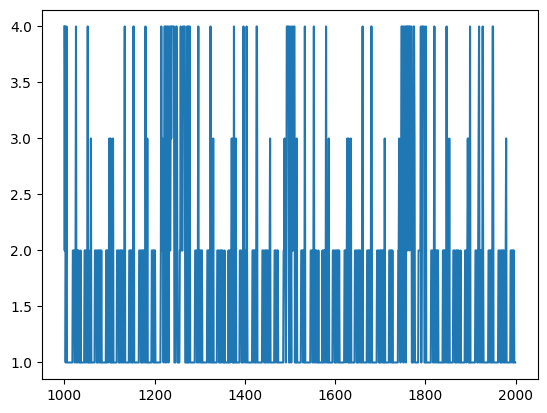

In [152]:
plt.plot(processed_kia_df[1000:2000]['CAN_ID_Norm'])

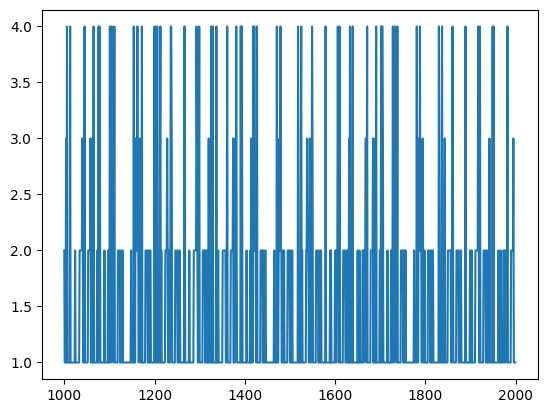

In [153]:
plt.plot(processed_tesla_df[1000:2000]['CAN_ID_Norm'])

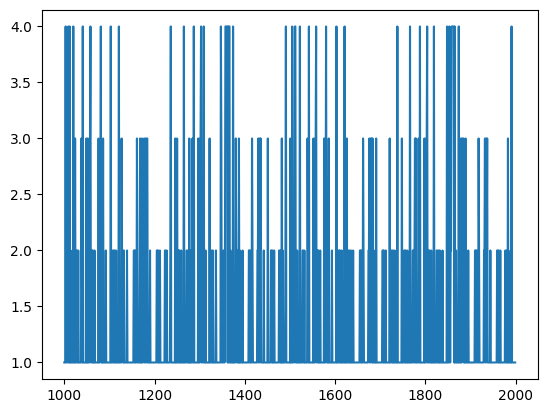

In [154]:
plt.plot(processed_gen_df[1000:2000]['CAN_ID_Norm'])

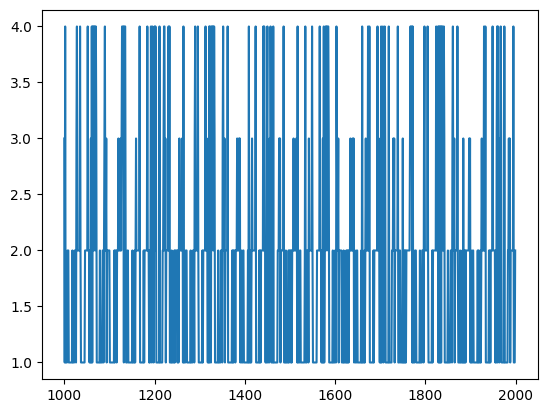

In [155]:
plt.plot(processed_sil_df[1000:2000]['CAN_ID_Norm'])

In [141]:
def get_high_frequency_can_ids(df, threshold=12000, column_name='CAN_ID'):
    """
    Finds unique CAN IDs that appear more times than a given threshold.

    Args:
        df (pd.DataFrame): The input DataFrame.
        threshold (int): The minimum count for an ID to be included.
        column_name (str): The name of the column containing the CAN IDs.

    Returns:
        np.ndarray: A NumPy array of the high-frequency CAN IDs, sorted
                    in ascending order.
    """
    # --- Step 1: Calculate the frequency of each unique CAN ID ---
    can_id_counts = df[column_name].value_counts()
    counts_df = can_id_counts.reset_index()
    counts_df.columns = [column_name, 'Count']

    # --- Step 2: Filter the DataFrame to keep only IDs above the threshold ---
    high_freq_df = counts_df[counts_df['Count'] >= threshold]

    # --- Step 3: Extract the CAN ID values into a NumPy array ---
    high_freq_ids = high_freq_df[column_name].values

    # --- Step 4: Sort the values in ascending order and return ---
    return np.sort(high_freq_ids)

In [142]:
get_high_frequency_can_ids(Kia_AF, threshold=12000)

array(['0130', '0140', '0153', '0162', '0164', '0220', '0251', '0260',
       '02B0', '0329', '0340', '0356', '0366', '0367', '0368'],
      dtype=object)

In [143]:
get_high_frequency_can_ids(Tesla_AF, threshold=12000)

array(['0031', '0051', '0101', '0108', '0111', '0118', '0129', '0136',
       '0142', '0175', '0186', '0187', '018A', '01E5', '0256', '02D5',
       '0370', '038C', '038D', '038E'], dtype=object)

In [144]:
get_high_frequency_can_ids(Gen_AF, threshold=12000)

array(['0040', '004A', '0060', '0065', '006A', '006F', '007A', '00A0',
       '00A5', '00B0', '00B5', '00EA', '0100', '011A', '0125', '012A',
       '0140', '0155'], dtype=object)

In [145]:
get_high_frequency_can_ids(Sil_AF, threshold=12000)

array(['00AA', '00BE', '00C1', '00C5', '00C7', '00C9', '00D1', '00D3',
       '00F1', '00F9', '018E', '01E5', '01ED'], dtype=object)

In [ ]:
## KIA ##
# counts_df_17500 = counts_df[counts_df['Count']>=17500]
# counts_df_7500_17500 = counts_df[counts_df['Count'].between(7500, 17500)]
# counts_df_1000_7500 = counts_df[counts_df['Count'].between(1000, 7500)]
# counts_df_600_1000 = counts_df[counts_df['Count'].between(600, 1000)]
# counts_df_600 = counts_df[counts_df['Count']<=600]

## TESLA ##
# counts_df[counts_df['Count']>=17500]
# counts_df[counts_df['Count'].between(7500, 17500)]
# counts_df[counts_df['Count'].between(3000, 6900)]
# counts_df[counts_df['Count'].between(1000, 3000)]
# counts_df[counts_df['Count']<=1000]

## Gennesis ##
# counts_df[counts_df['Count']>=17500]
# counts_df[counts_df['Count'].between(7500, 17500)]
# counts_df[counts_df['Count'].between(3000, 6900)]
# counts_df[counts_df['Count'].between(1000, 3000)]
# counts_df[counts_df['Count']<=1000]

## Silvarado ##
# counts_df[counts_df['Count']>=12000]
# counts_df[counts_df['Count'].between(5000, 12000)]
# counts_df[counts_df['Count'].between(2500, 5000)]
# counts_df[counts_df['Count'].between(1000, 2500)]
# counts_df[counts_df['Count']<=1000]

In [108]:
counts_df_12000 = counts_df[counts_df['Count']>=12000]
counts_df_5000_12000 = counts_df[counts_df['Count'].between(5000, 12000)]
counts_df_2500_5000 = counts_df[counts_df['Count'].between(2500, 5000)]
counts_df_2500 = counts_df[counts_df['Count']<=2500]

array(['0187', '0186', '02D5', '018A', '0256', '0142', '0118', '0136',
       '0108', '01E5', '0370', '0031', '038E', '0051', '0129', '038C',
       '0175', '038D', '0111', '0101'], dtype=object)

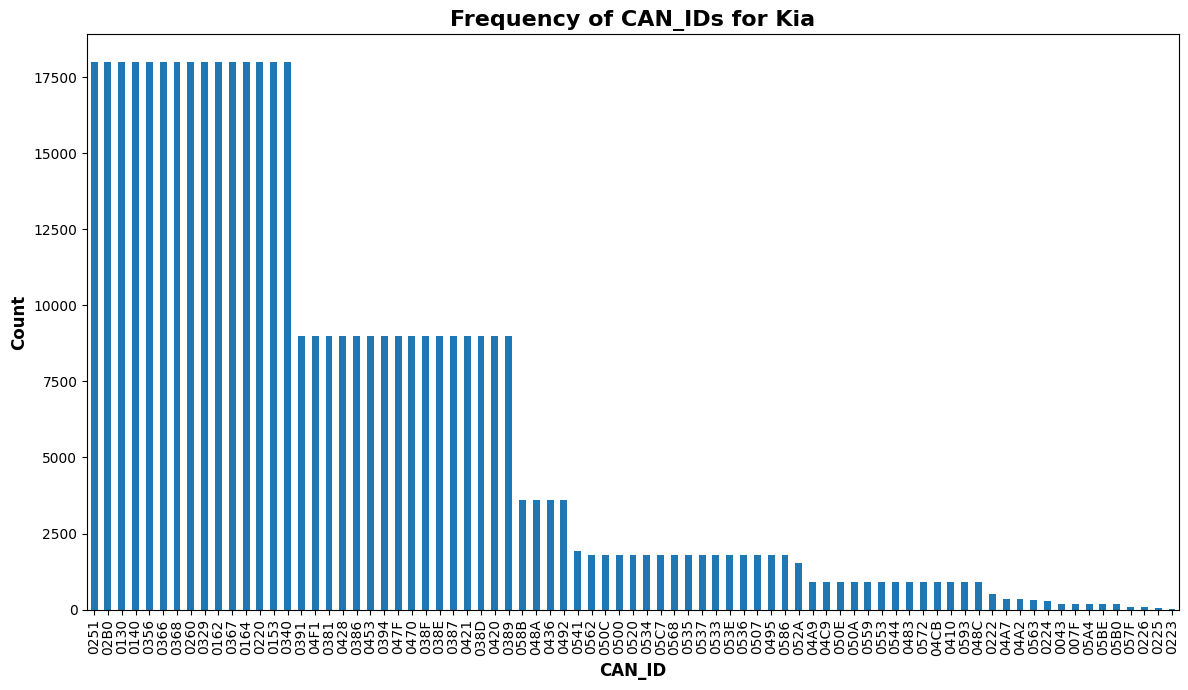

In [146]:
PlotCANIDFrequency(Kia_AF, Data_Name = "Kia")

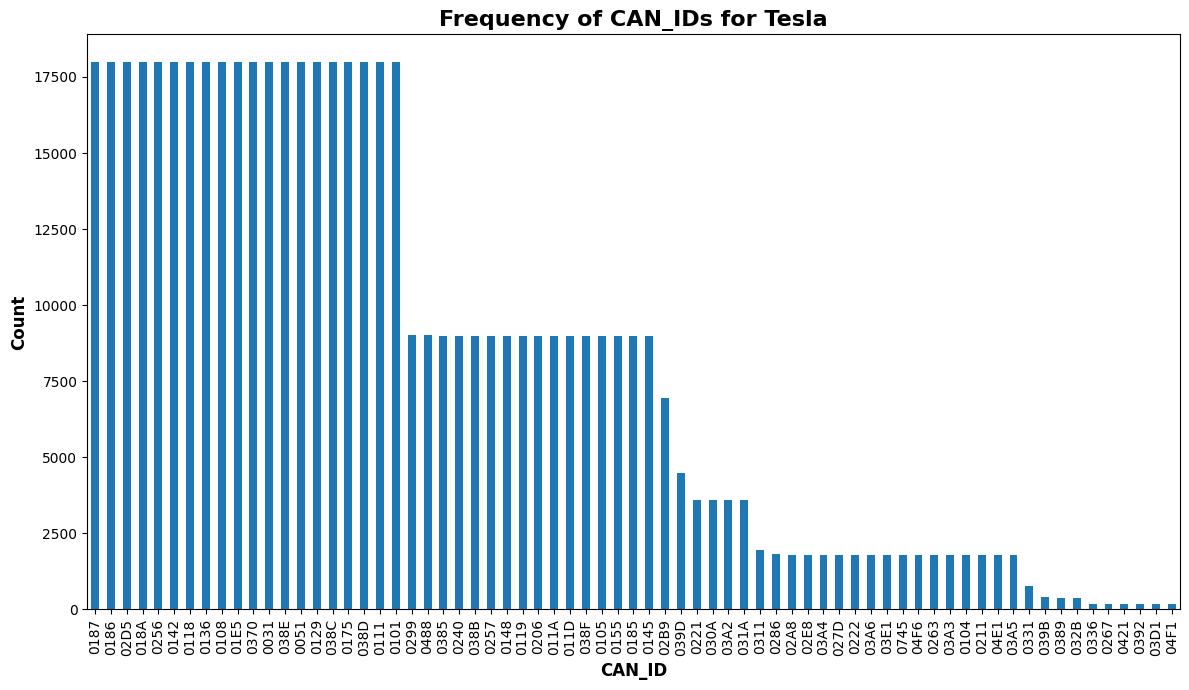

In [107]:
PlotCANIDFrequency(Tesla_AF, Data_Name = "Tesla")

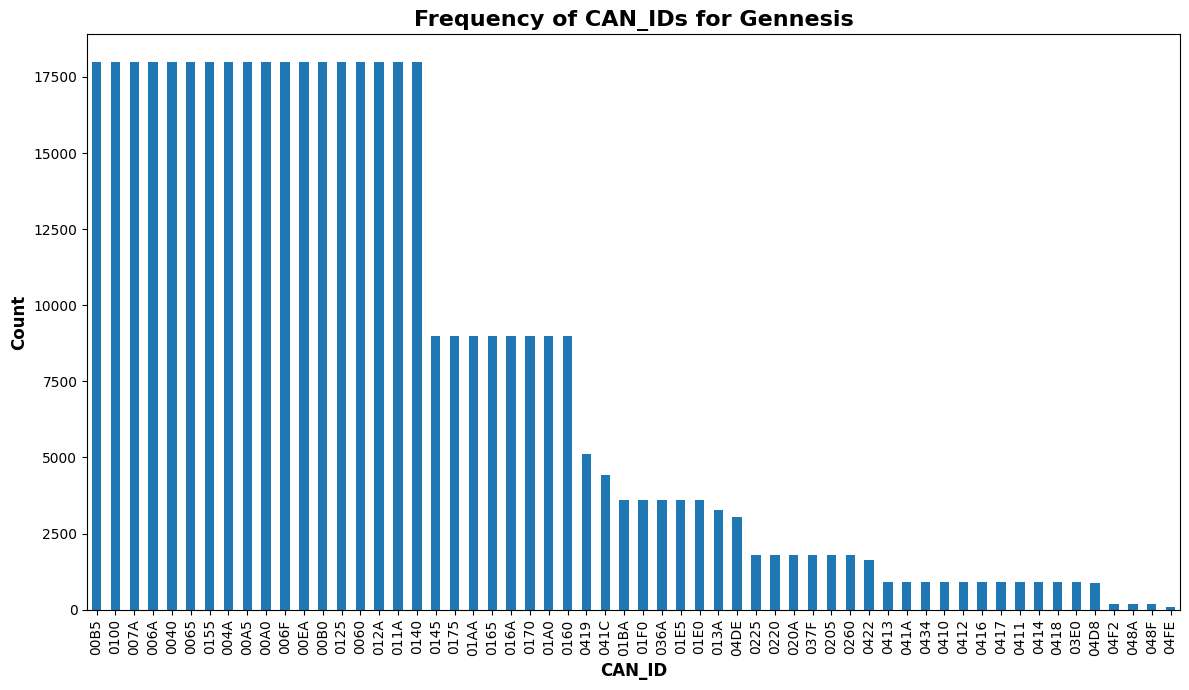

In [101]:
PlotCANIDFrequency(Gen_AF, Data_Name = "Gennesis")

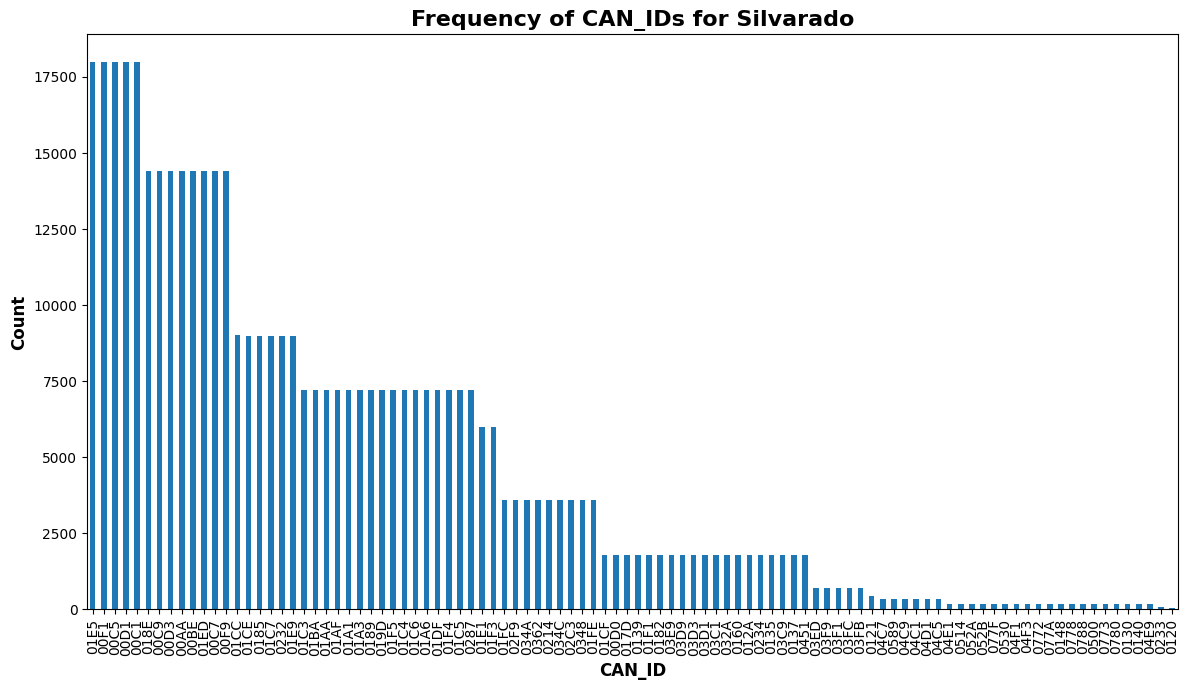

In [102]:
PlotCANIDFrequency(Sil_AF, Data_Name = "Silvarado")

Fuzzing

In [14]:
fuzz_result = DataInjection_CountFreq(
    type_of_attack="Fuzz",
    orig_df=simulation_df,
    injection_frequency=(3, 30),  # 5 fuzz attacks per 30 messages
    label="Fuzz"
)

Injecting 'Fuzz' messages… 100% complete
Done – injected 60000 Fuzz messages in 20000 groups.


In [15]:
simulation_df['Time_Gap'] = simulation_df['Time_Offset'].diff(1)
fuzz_result['Time_Gap'] = fuzz_result['Time_Offset'].diff(1)

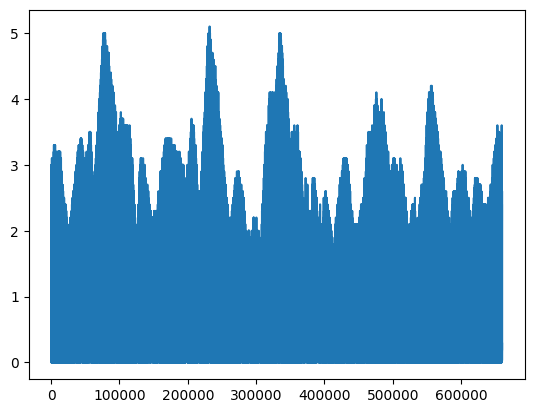

In [16]:
plt.plot(fuzz_result['Time_Gap'])

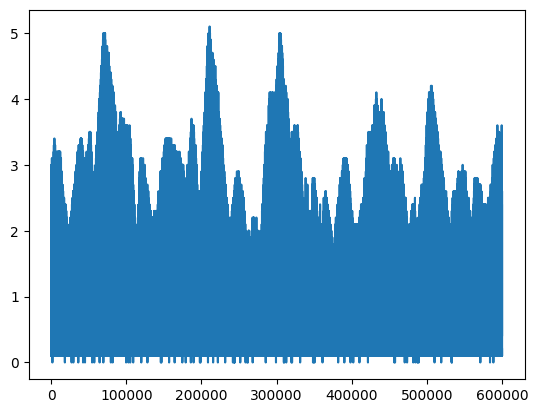

In [17]:
plt.plot(simulation_df['Time_Gap'])